<a href="https://colab.research.google.com/github/erskinekof/erskinekof.github.io/blob/master/Copy_of_dga_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from keras import models
from keras import layers
from keras.callbacks import ModelCheckpoint
from keras.models import Sequential, load_model
from keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Embedding, LSTM, Input, Reshape, Bidirectional, MaxPooling1D, Dropout
from keras.callbacks import EarlyStopping
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import pickle
from sklearn.compose import ColumnTransformer
import joblib

2024-06-24 09:33:54.453053: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-24 09:33:54.453222: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-24 09:33:54.601173: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
import os

file_path = '/content/dga_data.csv'
if os.path.exists(file_path):
    print(f'The file {file_path} exists.')
else:
    print(f'The file {file_path} does not exist.')

The file /content/dga_data.csv exists.


In [ ]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(title)
    plt.show()

def printRes(y_test, y_pred):
    # Оценка модели
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    print(f'Accuracy: {accuracy}')
    print('Classification Report:')
    print(report)
    plot_confusion_matrix(y_test, y_pred)


In [ ]:
def printFeatureImportances(model, vectorizer):
    feature_names = vectorizer.get_feature_names_out()
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    print("Feature importances:")
    for i in range(10):
        print(f"{i + 1}. {feature_names[indices[i]]} ({importances[indices[i]]})")

In [ ]:
def custom_tokenizer(text):
    # Разбиваем текст на токены по точкам и плюсам
    tokens = re.split(r'[.+]', text)
    # Убираем пустые токены
    tokens = [token for token in tokens if token]
    return tokens

def vectorising(X_train, X_test):
    vectorizer = TfidfVectorizer(max_features=len(X_train))
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)
    with open('model_dga_vectorizer.pkl', 'wb') as f:
        pickle.dump(vectorizer, f)
    return X_train_tfidf, X_test_tfidf, vectorizer

In [ ]:
def plotSubclassDistribution(y_true, y_pred, title):
    subclasses = np.unique(y_true)
    true_counts = [np.sum(y_true == subclass) for subclass in subclasses]
    pred_counts = [np.sum(y_pred == subclass) for subclass in subclasses]

    bar_width = 0.35
    index = np.arange(len(subclasses))

    plt.bar(index, true_counts, bar_width, label='True')
    plt.bar(index + bar_width, pred_counts, bar_width, label='Predicted')

    plt.xlabel('Subclass')
    plt.ylabel('Count')
    plt.title(title)
    plt.xticks(index + bar_width / 2, subclasses, rotation=90)
    plt.legend()
    plt.show()

In [ ]:
def printFeatureImportances(model):
    # Получение важности признаков для каждого векторайзера
    importances = model.named_steps['classifier'].feature_importances_
    vectorizer_second_domain = model.named_steps['preprocessor'].named_transformers_['second_domain']
    vectorizer_top_domain = model.named_steps['preprocessor'].named_transformers_['top_domain']

    feature_names_second_domain = vectorizer_second_domain.get_feature_names_out()
    feature_names_top_domain = vectorizer_top_domain.get_feature_names_out()

    # Объединение признаков в один DataFrame
    feature_names = list(feature_names_second_domain) + list(feature_names_top_domain)
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)

    print(importance_df)

In [ ]:
def randomForestModel1(X_train, y_train_isDGA, X_test, y_test_isDGA):


    model_dga = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=5, random_state=42))
    ])

    # Обучение модели
    model_dga.fit(X_train, y_train_isDGA)

    # Сохранение векторайзеров
    with open('model_dga_vectorizer.pkl', 'wb') as f:
        pickle.dump(preprocessor, f)

    # Предсказание
    y_pred_isDGA = model_dga.predict(X_test)

    print("DGA Classification Results:")
    printRes(y_test_isDGA, y_pred_isDGA)

#     # Модель для классификации подклассов
#     model_subclass = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=5, random_state=42)
#     model_subclass.fit(X_train_tfidf, y_train_subclass)
#     y_pred_subclass = model_subclass.predict(X_test_tfidf)
#     print("Subclass Classification Results:")
#     printRes(y_test_subclass, y_pred_subclass)
#     plotSubclassDistribution(y_test_subclass, y_pred_subclass, 'Random Forest Subclass Distribution')

In [ ]:
def randomForestModel(X_train, y_train_isDGA, y_train_subclass, X_test, y_test_isDGA, y_test_subclass):
    # Создание конвейера (pipeline)
    model_dga = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=5, random_state=42))
    ])

    # Обучение модели
    model_dga.fit(X_train, y_train_isDGA)

#     # Сохранение векторайзеров
#     with open('model_dga_vectorizer.pkl', 'wb') as f:
#         pickle.dump(preprocessor, f)

    # Предсказание
    y_pred_isDGA = model_dga.predict(X_test)

    print("DGA Classification Results:")
    printRes(y_test_isDGA, y_pred_isDGA)
    printFeatureImportances(model_dga)

In [ ]:
def gradientBoostingModel(X_train, y_train_isDGA, y_train_subclass, X_test, y_test_isDGA, y_test_subclass):
#     X_train_tfidf, X_test_tfidf, vectorizer = vectorising(X_train, X_test)

#     # Модель для классификации DGA/не DGA
#     model_dga = GradientBoostingClassifier(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42)
#     model_dga.fit(X_train_tfidf, y_train_isDGA)
#     y_pred_isDGA = model_dga.predict(X_test_tfidf)
#     print("DGA Classification Results:")
#     printRes(y_test_isDGA, y_pred_isDGA)
#     printFeatureImportances(model_dga, vectorizer)


        # Создание конвейера (pipeline)
    model_dga = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42))
    ])

    # Обучение модели
    model_dga.fit(X_train, y_train_isDGA)

#     # Сохранение векторайзеров
#     with open('model_dga_vectorizer.pkl', 'wb') as f:
#         pickle.dump(preprocessor, f)

    # Предсказание
    y_pred_isDGA = model_dga.predict(X_test)

    print("DGA Classification Results:")
    printRes(y_test_isDGA, y_pred_isDGA)
    printFeatureImportances(model_dga)

#     # Модель для классификации подклассов
#     model_subclass = GradientBoostingClassifier(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42)
#     model_subclass.fit(X_train_tfidf, y_train_subclass)
#     y_pred_subclass = model_subclass.predict(X_test_tfidf)
#     print("Subclass Classification Results:")
#     printRes(y_test_subclass, y_pred_subclass)
#     plotSubclassDistribution(y_test_subclass, y_pred_subclass, 'Gradient Boosting Subclass Distribution')

In [ ]:
def logisticRegressionModel(X_train, y_train_isDGA, y_train_subclass, X_test, y_test_isDGA, y_test_subclass):
#     X_train_tfidf, X_test_tfidf, vectorizer = vectorising(X_train, X_test)

#     # Модель для классификации DGA/не DGA
#     model_dga = LogisticRegression(max_iter=1000, random_state=42)
#     model_dga.fit(X_train_tfidf, y_train_isDGA)
#     y_pred_isDGA = model_dga.predict(X_test_tfidf)
#     print("DGA Classification Results:")
#     printRes(y_test_isDGA, y_pred_isDGA)


            # Создание конвейера (pipeline)
    model_dga = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])

    # Обучение модели
    model_dga.fit(X_train, y_train_isDGA)

#     # Сохранение векторайзеров
#     with open('model_dga_vectorizer.pkl', 'wb') as f:
#         pickle.dump(preprocessor, f)

    # Предсказание
    y_pred_isDGA = model_dga.predict(X_test)

    print("DGA Classification Results:")
    printRes(y_test_isDGA, y_pred_isDGA)
    printFeatureImportances(model_dga)
#     # Модель для классификации подклассов
#     model_subclass = LogisticRegression(max_iter=1000, random_state=42)
#     model_subclass.fit(X_train_tfidf, y_train_subclass)
#     y_pred_subclass = model_subclass.predict(X_test_tfidf)
#     print("Subclass Classification Results:")
#     printRes(y_test_subclass, y_pred_subclass)
#     plotSubclassDistribution(y_test_subclass, y_pred_subclass, 'Logistic Regression Subclass Distribution')

In [ ]:
def adaBoostingModel(X_train, y_train_isDGA, y_train_subclass, X_test, y_test_isDGA, y_test_subclass):
#     X_train_tfidf, X_test_tfidf, vectorizer = vectorising(X_train, X_test)

#     # Модель для классификации DGA/не DGA
#     model_dga = AdaBoostClassifier(n_estimators=200, random_state=42)
#     model_dga.fit(X_train_tfidf, y_train_isDGA)
#     y_pred_isDGA = model_dga.predict(X_test_tfidf)
#     print("DGA Classification Results:")
#     printRes(y_test_isDGA, y_pred_isDGA)
#     printFeatureImportances(model_dga, vectorizer)

            # Создание конвейера (pipeline)
    model_dga = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', AdaBoostClassifier(n_estimators=200, random_state=42))
    ])

    # Обучение модели
    model_dga.fit(X_train, y_train_isDGA)

#     # Сохранение векторайзеров
#     with open('model_dga_vectorizer.pkl', 'wb') as f:
#         pickle.dump(preprocessor, f)

    # Предсказание
    y_pred_isDGA = model_dga.predict(X_test)

    print("DGA Classification Results:")
    printRes(y_test_isDGA, y_pred_isDGA)
    printFeatureImportances(model_dga)

#         # Сохранение модели для классификации DGA/не DGA в файл
#     with open('model_dga_AdaBoost.pkl', 'wb') as f:
#         pickle.dump(model_dga, f)

#     # Модель для классификации подклассов
#     model_subclass = AdaBoostClassifier(n_estimators=200, random_state=42)
#     model_subclass.fit(X_train_tfidf, y_train_subclass)
#     y_pred_subclass = model_subclass.predict(X_test_tfidf)
#     print("Subclass Classification Results:")
#     printRes(y_test_subclass, y_pred_subclass)
#     plotSubclassDistribution(y_test_subclass, y_pred_subclass, 'Ada Boosting Subclass Distribution')

In [ ]:
from sklearn.svm import SVC

def svmModel(X_train_tfidf, y_train, X_test_tfidf, y_test):
    # Model for DGA/non-DGA classification
    model_dga = SVC(kernel='linear', random_state=42)
    model_dga.fit(X_train_tfidf, y_train)
    y_pred_isDGA = model_dga.predict(X_test_tfidf)

    print("SVM Classification Results:")
    printRes(y_test, y_pred_isDGA)

    # Save the trained SVM model
    joblib.dump(model_dga, 'dga_model_svm.pkl')

SVM Model:
SVM Classification Results:
Accuracy: 0.994625
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     16123
           1       0.99      0.99      0.99     15877

    accuracy                           0.99     32000
   macro avg       0.99      0.99      0.99     32000
weighted avg       0.99      0.99      0.99     32000



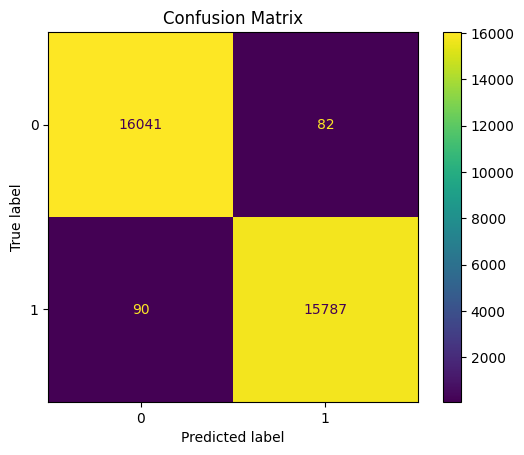

In [ ]:
# SVM Model
print("SVM Model:")
# The X_train_tfidf and X_test_tfidf are already available from the RandomForest training cell (0f3001ef)
svmModel(X_train_tfidf, y_train, X_test_tfidf, y_test)


/tmp/ipykernel_4650/3264149287.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracy_scores, palette='viridis')


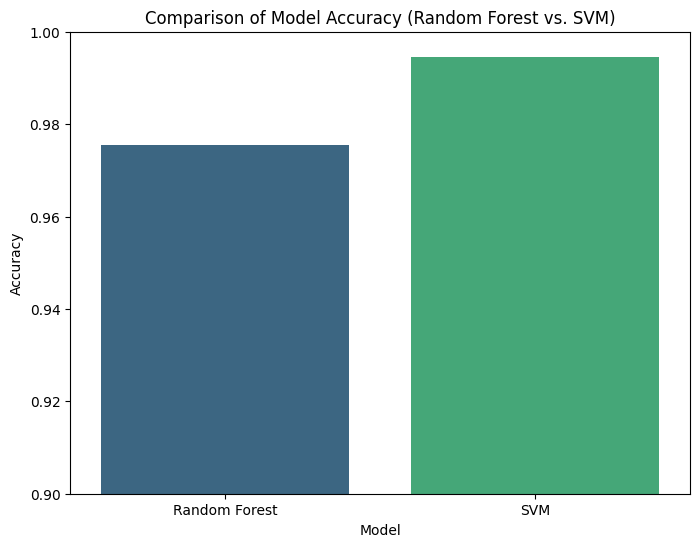

In [ ]:
import seaborn as sns

model_names = ['Random Forest', 'SVM']
accuracy_scores = [0.9755, 0.994625] # From previous outputs

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracy_scores, palette='viridis')
plt.ylim(0.90, 1.0)
plt.title('Comparison of Model Accuracy (Random Forest vs. SVM)')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
# Загрузка данных
df = pd.read_csv('/kaggle/input/dga-dataset/dga_data.csv')  # Укажите путь к вашему файлу с данными
df_val = pd.read_csv('/kaggle/input/validating-time/validatingWithTime.csv')  # Укажите путь к вашему файлу с данными

In [ ]:
X1 = df[['Query']]
y1 = df[['Target']]
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

,Target,Query,Time
0,1,wc5diss2ai2p7rk4qye13u6 wc5diss2ai2p7rk4qye13u...,2024-06-19 00:33:47
1,1,kb5fpy1iumnv71lmcaxzu2u41o kb5fpy1iumnv71lmcax...,2024-06-19 23:28:29
2,1,qlahpubfquwu qlahpubfquwu.ru,2024-06-19 22:30:56
3,1,bp3zn8hy746110x3i5f11ps0l9 bp3zn8hy746110x3i5f...,2024-06-19 19:38:29
4,0,revenda5reais revenda5reais.com,2024-06-19 00:54:17
...,...,...,...
36994,1,r53953.tunnel.tuns.org.,2024-06-19 15:54:01
36995,1,r53954.tunnel.tuns.org.,2024-06-19 03:20:53
36996,1,r53955.tunnel.tuns.org.,2024-06-19 06:41:58
36997,1,r53956.tunnel.tuns.org.,2024-06-19 12:12:10


In [ ]:
df.subclass.value_counts()

subclass
alexa           42616
legit           37384
cryptolocker    37254
newgoz           9276
gameoverdga      8461
nivdort          8456
necurs           8331
goz              6136
bamital          2086
Name: count, dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160000 entries, 0 to 159999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   isDGA     160000 non-null  object
 1   domain    159998 non-null  object
 2   host      160000 non-null  object
 3   subclass  160000 non-null  object
dtypes: object(4)
memory usage: 4.9+ MB


In [ ]:
df = df.dropna()

In [ ]:
df

,isDGA,domain,host,subclass,second_domain,top_domain
0,1,6xzxsw3sokvg1tc752y1a6p0af,6xzxsw3sokvg1tc752y1a6p0af.com,gameoverdga,6xzxsw3sokvg1tc752y1a6p0af,com
1,1,glbtlxwwhbnpxs,glbtlxwwhbnpxs.ru,cryptolocker,glbtlxwwhbnpxs,ru
2,1,xxmamopyipbfpk,xxmamopyipbfpk.ru,cryptolocker,xxmamopyipbfpk,ru
3,1,zfd5szpi18i85wj9uy13l69rg,zfd5szpi18i85wj9uy13l69rg.net,newgoz,zfd5szpi18i85wj9uy13l69rg,net
4,1,jpqftymiuver,jpqftymiuver.ru,cryptolocker,jpqftymiuver,ru
...,...,...,...,...,...,...
159995,0,manhunt,manhunt.net,alexa,manhunt,net
159996,0,yupptv,yupptv.com,alexa,yupptv,com
159997,0,bbcmundo,bbcmundo.com,legit,bbcmundo,com
159998,0,kanogames,kanogames.com,legit,kanogames,com


In [ ]:
# Преобразование меток
df['isDGA'] = df['isDGA'].apply(lambda x: 1 if x == 'dga' else 0)
df

,isDGA,domain,host,subclass
0,1,6xzxsw3sokvg1tc752y1a6p0af,6xzxsw3sokvg1tc752y1a6p0af.com,gameoverdga
1,1,glbtlxwwhbnpxs,glbtlxwwhbnpxs.ru,cryptolocker
2,1,xxmamopyipbfpk,xxmamopyipbfpk.ru,cryptolocker
3,1,zfd5szpi18i85wj9uy13l69rg,zfd5szpi18i85wj9uy13l69rg.net,newgoz
4,1,jpqftymiuver,jpqftymiuver.ru,cryptolocker
...,...,...,...,...
159995,0,manhunt,manhunt.net,alexa
159996,0,yupptv,yupptv.com,alexa
159997,0,bbcmundo,bbcmundo.com,legit
159998,0,kanogames,kanogames.com,legit


In [ ]:
df['isDGA'].value_counts()

isDGA
1    80000
0    79998
Name: count, dtype: int64

In [ ]:
df[df['isDGA'] == 1].groupby('subclass').count()

,isDGA,domain,host
subclass,,,
bamital,2086,2086,2086
cryptolocker,37254,37254,37254
gameoverdga,8461,8461,8461
goz,6136,6136,6136
necurs,8331,8331,8331
newgoz,9276,9276,9276
nivdort,8456,8456,8456


In [ ]:
df[df['isDGA'] == 0].groupby('subclass').count()

,isDGA,domain,host
subclass,,,
alexa,42614,42614,42614
legit,37384,37384,37384


In [ ]:
def split_domain(host):
    parts = host.split('.')
    if len(parts) >= 2:
        # Домены второго уровня и первого уровня
        domain_second_level = parts[-2]
        domain_top_level = parts[-1]
        return domain_second_level, domain_top_level
    else:
        return None, None

In [ ]:
# Применение функции ко всем хостам в DataFrame и создание новых столбцов
df[['second_domain', 'top_domain']] = df['host'].apply(lambda x: pd.Series(split_domain(x)))

In [ ]:
df[df['isDGA'] == 0].groupby('top_domain')['top_domain'].count().sort_values(ascending=False).head(10)

top_domain
com     50400
net      4611
org      2535
ru       2394
cn       1676
de       1669
jp       1460
br       1110
uk        817
info      708
Name: top_domain, dtype: int64

In [ ]:
df[df['isDGA'] == 1].groupby('top_domain')['top_domain'].count().sort_values(ascending=False).head(10)

top_domain
ru      36408
net     15757
org      7930
com      5808
biz      4353
uk       1201
info     1178
pw        224
mn        223
sc        220
Name: top_domain, dtype: int64

In [ ]:
df.columns

Index(['isDGA', 'domain', 'host', 'subclass', 'second_domain', 'top_domain'], dtype='object')

In [ ]:
# Разделение данных на обучающую и тестовую выборки
X = df[['second_domain', 'top_domain', 'subclass']]
y = df[['isDGA', 'subclass']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Преобразование y_train и y_test
y_train_isDGA = y_train['isDGA']
y_test_isDGA = y_test['isDGA']
y_train_subclass = y_train['subclass']
y_test_subclass = y_test['subclass']

In [ ]:
# Разделение данных на обучающую и тестовую выборки
X = df['domain'] +  df['host']
y = df['isDGA']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Определение ColumnTransformer с TfidfVectorizer для каждого текстового столбца
preprocessor = ColumnTransformer(
    transformers=[
        (X_train, TfidfVectorizer(), X_train)
    ]
)

In [ ]:
print("Random Forest Model:")
randomForestModel1(X_train, y_train, X_test, y_test)

Random Forest Model:


TypeError: unhashable type: 'Series'

In [ ]:
from datetime import datetime, timedelta
num_samples = len(y_test)
base_date = datetime(2024, 6, 19)
times = [base_date + timedelta(seconds=np.random.randint(0, 86400)) for _ in range(num_samples)]

df_app = pd.DataFrame({'Target': y_test['isDGA'], 'Query': X_test['domain'] + ' ' + X_test['host'], 'Time': [time.strftime('%Y-%m-%d %H:%M:%S') for time in times]})
df_app

,Target,Query,Time
49889,1,wc5diss2ai2p7rk4qye13u6 wc5diss2ai2p7rk4qye13u...,2024-06-19 00:33:47
32693,1,kb5fpy1iumnv71lmcaxzu2u41o kb5fpy1iumnv71lmcax...,2024-06-19 23:28:29
79957,1,qlahpubfquwu qlahpubfquwu.ru,2024-06-19 22:30:56
76365,1,bp3zn8hy746110x3i5f11ps0l9 bp3zn8hy746110x3i5f...,2024-06-19 19:38:29
82342,0,revenda5reais revenda5reais.com,2024-06-19 00:54:17
...,...,...,...
87335,0,dlisted dlisted.com,2024-06-19 19:50:00
127214,0,shinseibank shinseibank.com,2024-06-19 21:59:38
11241,1,ktwhmhetkfipkbtfmxucpbkr ktwhmhetkfipkbtfmxucp...,2024-06-19 16:00:27
131827,0,arabs-up arabs-up.com,2024-06-19 18:01:00


In [ ]:
df_app.to_csv('df_app.csv', index=False)

In [ ]:
# Определение ColumnTransformer с TfidfVectorizer для каждого текстового столбца
preprocessor = ColumnTransformer(
    transformers=[
        ('second_domain', TfidfVectorizer(), 'second_domain'),
        ('top_domain', TfidfVectorizer(), 'top_domain'),
        ('subclass', TfidfVectorizer(), 'subclass')
    ]
)

Random Forest Model:
DGA Classification Results:
Accuracy: 0.95665625
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96     16123
           1       0.97      0.94      0.96     15877

    accuracy                           0.96     32000
   macro avg       0.96      0.96      0.96     32000
weighted avg       0.96      0.96      0.96     32000



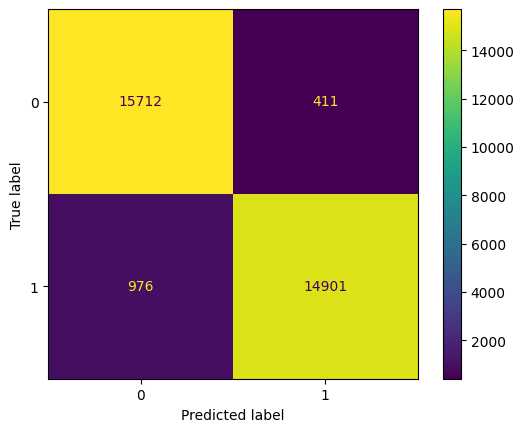

ValueError: All arrays must be of the same length

In [ ]:
# Random Forest
print("Random Forest Model:")
randomForestModel(X_train, y_train_isDGA, y_train_subclass, X_test, y_test_isDGA, y_test_subclass)

Gradient Boosting Model:
DGA Classification Results:
Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16123
           1       1.00      1.00      1.00     15877

    accuracy                           1.00     32000
   macro avg       1.00      1.00      1.00     32000
weighted avg       1.00      1.00      1.00     32000



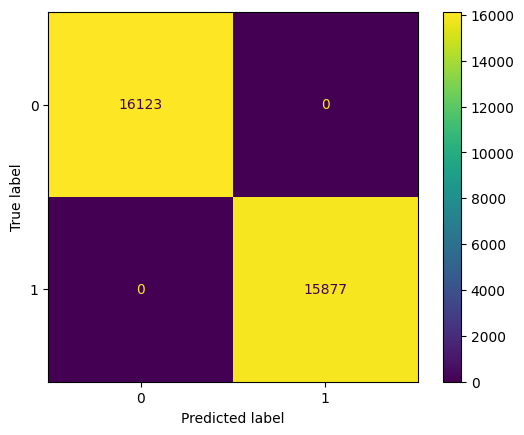

ValueError: All arrays must be of the same length

In [ ]:
# Gradient Boosting
print("Gradient Boosting Model:")
gradientBoostingModel(X_train, y_train_isDGA, y_train_subclass, X_test, y_test_isDGA, y_test_subclass)

Logistic Regression Model:
DGA Classification Results:
Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16123
           1       1.00      1.00      1.00     15877

    accuracy                           1.00     32000
   macro avg       1.00      1.00      1.00     32000
weighted avg       1.00      1.00      1.00     32000



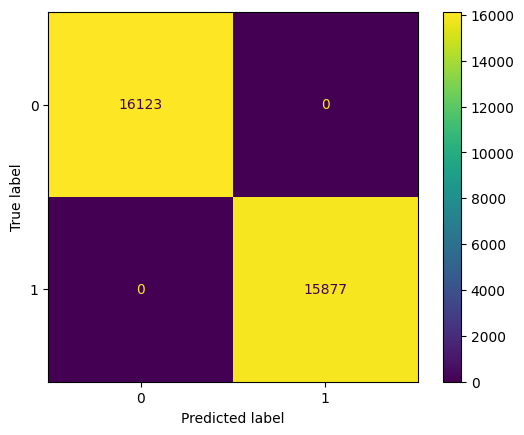

AttributeError: 'LogisticRegression' object has no attribute 'feature_importances_'

In [ ]:
# Logistic Regression
print("Logistic Regression Model:")
logisticRegressionModel(X_train, y_train_isDGA, y_train_subclass, X_test, y_test_isDGA, y_test_subclass)

Ada Boost Model:
DGA Classification Results:
Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16123
           1       1.00      1.00      1.00     15877

    accuracy                           1.00     32000
   macro avg       1.00      1.00      1.00     32000
weighted avg       1.00      1.00      1.00     32000



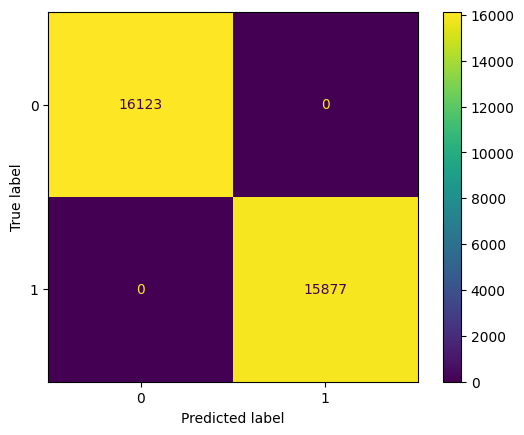

ValueError: All arrays must be of the same length

In [ ]:
print("Ada Boost Model:")
adaBoostingModel(X_train, y_train_isDGA, y_train_subclass, X_test, y_test_isDGA, y_test_subclass)

In [ ]:
df.domain.value_counts()

domain
6xzxsw3sokvg1tc752y1a6p0af          1
kingofgames                         1
caffmoscommunity                    1
meteogiornale                       1
corpbank                            1
                                   ..
nzuemljsottrcudmrlmrprwde           1
thistear                            1
02c7ee2ee3f166e80143f2c5ed59ade2    1
xvikcuomrvhbihp                     1
roadrover                           1
Name: count, Length: 159998, dtype: int64

In [ ]:
# Загрузка данных
df = pd.read_csv('/kaggle/input/dga-dataset/dga_data.csv')
df = df.dropna()

In [ ]:
# Преобразование меток подклассов в числовой формат
label_encoder = LabelEncoder()
df['subclass_encoded'] = label_encoder.fit_transform(df['subclass'])

# Разделение данных на обучающую и тестовую выборки
X = df[['domain', 'host']]
y = df['subclass_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Преобразование текстовых данных в последовательности чисел (токенизация)
max_words = 160000
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train['domain'] + ' ' + X_train['host'])
X_train_seq = tokenizer.texts_to_sequences(X_train['domain'] + ' ' + X_train['host'])
X_test_seq = tokenizer.texts_to_sequences(X_test['domain'] + ' ' + X_test['host'])

# Подготовка данных (приведение к одной длине последовательностей)
max_len = 50
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [ ]:
def create_lstm_model(max_words, max_len):
    model = Sequential()
    model.add(Embedding(max_words, 100))
    model.add(LSTM(100))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(len(label_encoder.classes_), activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
# Создание модели
lstm_model = create_lstm_model(max_words, max_len)

# Определение колбэка для сохранения лучшей модели
checkpoint_path = 'best_model.keras'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

# Обучение модели с использованием колбэка ModelCheckpoint
epochs = 10
batch_size = 128

history = lstm_model.fit(X_train_pad, y_train, epochs=epochs, batch_size=batch_size,
                         validation_data=(X_test_pad, y_test), verbose=1,
                         callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True), checkpoint])

# Загрузка лучшей модели
lstm_model.load_weights(checkpoint_path)

# Оценка модели
loss, accuracy = lstm_model.evaluate(X_test_pad, y_test)
print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

Epoch 1/10


/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2486 - loss: 1.8943
Epoch 1: val_accuracy improved from -inf to 0.26888, saving model to best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.2487 - loss: 1.8943 - val_accuracy: 0.2689 - val_loss: 1.8434
Epoch 2/10
 998/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2598 - loss: 1.8525
Epoch 2: val_accuracy did not improve from 0.26888
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.2598 - loss: 1.8525 - val_accuracy: 0.2689 - val_loss: 1.8402
Epoch 3/10
 997/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2663 - loss: 1.8494
Epoch 3: val_accuracy did not improve from 0.26888
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.2663 - loss: 1.8494 - val_accuracy: 0.2689 - val_loss: 1.8401
Epoch 4/10
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2659 - loss: 1.8530
Epoch 4: val_accuracy did not improve from 0.26888
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accura

Epoch 1/10


/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8272 - loss: 0.3885 - val_accuracy: 0.8858 - val_loss: 0.2954
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9938 - loss: 0.0250 - val_accuracy: 0.7825 - val_loss: 0.5510
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 1.0000 - loss: 3.4509e-04 - val_accuracy: 0.8088 - val_loss: 0.6164
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 1.0000 - loss: 9.9333e-05 - val_accuracy: 0.8082 - val_loss: 0.6788
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 1.0000 - loss: 7.3822e-05 - val_accuracy: 0.7244 - val_loss: 0.9338
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 1.0000 - loss: 2.3300e-05 - val_accuracy: 0.7356 - val_loss: 0.9176
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 1.0000 - loss: 1.7891e-04 - val_accuracy: 0.7840 - val_loss: 0.7017
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 1.0000 - loss

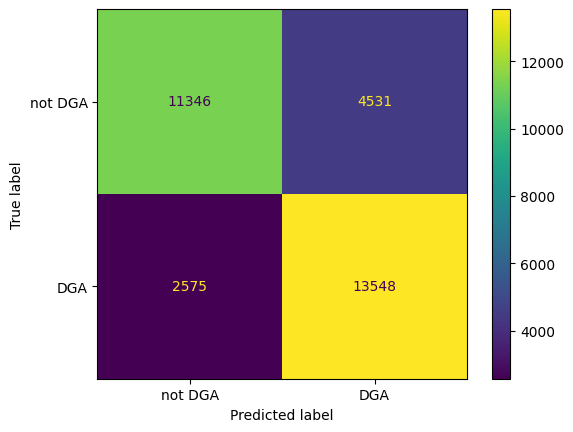

In [ ]:
def create_dga_detection_model(max_words, max_len):
    model = Sequential()
    model.add(Embedding(max_words, 100, input_length=max_len))
    model.add(LSTM(100))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))  # Выходной слой для бинарной классификации

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Предобработка данных
max_words = 100000  # Максимальное количество слов в словаре
max_len = 30  # Максимальная длина последовательности

# Токенизация и преобразование доменных имен в последовательности чисел
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['domain'])
X = tokenizer.texts_to_sequences(df['domain'])
X = pad_sequences(X, maxlen=max_len)

tokenizer.fit_on_texts(X_train['domain'] + ' ' + X_train['host'])
X_train_seq = tokenizer.texts_to_sequences(X_train['domain'] + ' ' + X_train['host'])
X_test_seq = tokenizer.texts_to_sequences(X_test['domain'] + ' ' + X_test['host'])

# Кодирование целевой переменной (isDGA)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['isDGA'])

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создание модели
model = create_dga_detection_model(max_words, max_len)

# Определение колбэка для сохранения лучшей модели
checkpoint_path = 'best_model.keras'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

# Обучение модели
epochs = 10
batch_size = 128

history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                    validation_data=(X_test, y_test), verbose=1,
                    callbacks=[checkpoint])

# Оценка модели
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss:.4f}')
print(f'Accuracy: {accuracy:.4f}')

# Предсказание на тестовых данных
y_pred = (model.predict(X_test) > 0.5).astype('int32')

# Отчет о классификации и матрица ошибок
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['not DGA', 'DGA'])
disp.plot()
plt.show()

In [ ]:
def randomForestModel(X_train, y_train, X_test, y_test):
    X_train_tfidf, X_test_tfidf, vectorizer = vectorising(X_train, X_test)

    model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5, random_state=42)
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    print("Subclass Classification Results:")
    printRes(y_test, y_pred)
    plotSubclassAccuracy(y_test, y_pred, 'Random Forest Subclass Accuracy')


In [ ]:
# Разделение данных на обучающую и тестовую выборки
X = df[['domain', 'host']]
y = df['isDGA']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
def vectorising(X_train, X_test):
    vectorizer = TfidfVectorizer(max_features=len(X_train))
    X_train_tfidf = vectorizer.fit_transform(X_train['domain'] + ' ' + X_train['host'])
    X_test_tfidf = vectorizer.transform(X_test['domain'] + ' ' + X_test['host'])
    return X_train_tfidf, X_test_tfidf, vectorizer

def printRes(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    print(f'Accuracy: {accuracy}')
    print('Classification Report:')
    print(report)
    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_true))
    disp.plot()
    plt.show()

def plotSubclassAccuracy(y_true, y_pred, title):
    subclasses = np.unique(y_true)
    subclass_accuracy = {subclass: accuracy_score(y_true, y_pred) for subclass in subclasses}

    plt.figure(figsize=(10, 6))
    plt.bar(subclass_accuracy.keys(), subclass_accuracy.values())
    plt.xlabel('Subclass')
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.xticks(rotation=90)
    plt.ylim(0, 1)
    plt.show()

In [ ]:
def randomForestModel(X_train, y_train, X_test, y_test):
    X_train_tfidf, X_test_tfidf, vectorizer = vectorising(X_train, X_test)

#     with open('model_dga_vectorizer.pkl', 'wb') as f:
#         pickle.dump(vectorizer, f)
    joblib.dump(vectorizer, 'model_dga_vectorizer.pkl')

    model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42)
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

#     with open('model_Random_Forest.pkl', 'wb') as f:
#         pickle.dump(model, f)

    joblib.dump(model, 'model_Random_Forest.pkl')

    print("Subclass Classification Results:")
    printRes(y_test, y_pred)
    plotSubclassAccuracy(y_test, y_pred, 'Random Forest Subclass Accuracy')

Subclass Classification Results:
Accuracy: 0.867
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.82      0.86     16123
           1       0.83      0.92      0.87     15877

    accuracy                           0.87     32000
   macro avg       0.87      0.87      0.87     32000
weighted avg       0.87      0.87      0.87     32000



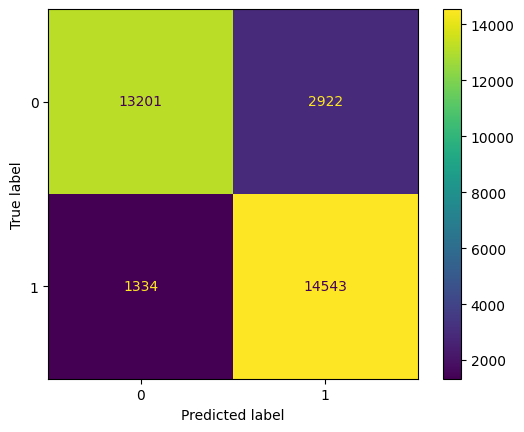

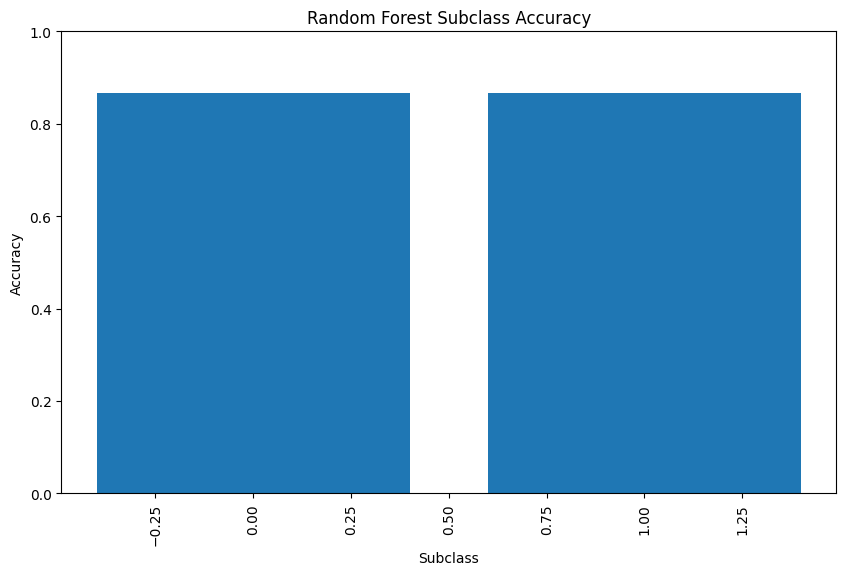

In [ ]:
X_train_tfidf, X_test_tfidf, vectorizer = vectorising(X_train, X_test)

#     with open('model_dga_vectorizer.pkl', 'wb') as f:
#         pickle.dump(vectorizer, f)
joblib.dump(vectorizer, 'model_dga_vectorizer.pkl')

model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42)
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

#     with open('model_Random_Forest.pkl', 'wb') as f:
#         pickle.dump(model, f)

joblib.dump(model, 'model_Random_Forest.pkl')

print("Subclass Classification Results:")
printRes(y_test, y_pred)
plotSubclassAccuracy(y_test, y_pred, 'Random Forest Subclass Accuracy')

In [ ]:
df_val['Target'] = df_val['Target'].apply(lambda x: 'dga' if x == 1 else 'legit')
df_val

,Target,Query,Time
0,dga,wc5diss2ai2p7rk4qye13u6 wc5diss2ai2p7rk4qye13u...,2024-06-19 00:33:47
1,dga,kb5fpy1iumnv71lmcaxzu2u41o kb5fpy1iumnv71lmcax...,2024-06-19 23:28:29
2,dga,qlahpubfquwu qlahpubfquwu.ru,2024-06-19 22:30:56
3,dga,bp3zn8hy746110x3i5f11ps0l9 bp3zn8hy746110x3i5f...,2024-06-19 19:38:29
4,legit,revenda5reais revenda5reais.com,2024-06-19 00:54:17
...,...,...,...
36994,dga,r53953.tunnel.tuns.org.,2024-06-19 15:54:01
36995,dga,r53954.tunnel.tuns.org.,2024-06-19 03:20:53
36996,dga,r53955.tunnel.tuns.org.,2024-06-19 06:41:58
36997,dga,r53956.tunnel.tuns.org.,2024-06-19 12:12:10


Accuracy: 0.9523770912727371
Classification Report:
              precision    recall  f1-score   support

         dga       0.98      0.93      0.95     19876
       legit       0.92      0.98      0.95     17123

    accuracy                           0.95     36999
   macro avg       0.95      0.95      0.95     36999
weighted avg       0.95      0.95      0.95     36999



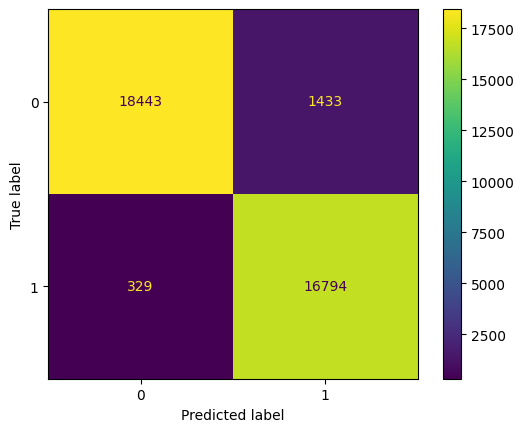

In [ ]:
x_val = df_val['Query']
x_val = vectorizer.transform(x_val)
y_pred_val = model.predict(x_val)
printRes(df_val['Target'], y_pred_val)

In [ ]:
joblib.dump(model, 'model_Random_Forest.pkl')

['model_Random_Forest.pkl']

In [ ]:
df_val.head(32000)['Target'].value_counts()

Target
0    16123
1    15877
Name: count, dtype: int64

In [ ]:
df_val.head(32000)['Target'].value_counts()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

# Функция для векторизации текстовых данных
def vectorising(train_data, test_data, ngram_range=(2, 5)):
    vectorizer = TfidfVectorizer(analyzer='char', ngram_range=ngram_range, max_features=len(train_data))
    X_train_tfidf = vectorizer.fit_transform(train_data)
    X_test_tfidf = vectorizer.transform(test_data)
    return X_train_tfidf, X_test_tfidf, vectorizer

# Функция для печати результатов
def printRes(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    print(f'Accuracy: {accuracy}')
    print('Classification Report:')
    print(report)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()

In [ ]:
# Чтение данных
df = pd.read_csv('/kaggle/input/dga-dataset/dga_data.csv')
df = df.dropna()

In [ ]:
# Объединение подклассов
df['subclass'] = df['subclass'].replace({
    'alexa': 'alexa/legit',
    'legit': 'alexa/legit',
    'gameoverdga': 'newgoz'
})

# Проверка результатов
print(df['subclass'].value_counts())

subclass
alexa/legit     79998
cryptolocker    37254
newgoz          17737
nivdort          8456
necurs           8331
goz              6136
bamital          2086
Name: count, dtype: int64


In [ ]:
df['isDGA'] = df['isDGA'].apply(lambda x: 1 if x == 'dga' else 0)
label_encoder = LabelEncoder()
df['subclass'] = label_encoder.fit_transform(df['subclass'])
df

,isDGA,domain,host,subclass
0,1,6xzxsw3sokvg1tc752y1a6p0af,6xzxsw3sokvg1tc752y1a6p0af.com,5
1,1,glbtlxwwhbnpxs,glbtlxwwhbnpxs.ru,2
2,1,xxmamopyipbfpk,xxmamopyipbfpk.ru,2
3,1,zfd5szpi18i85wj9uy13l69rg,zfd5szpi18i85wj9uy13l69rg.net,5
4,1,jpqftymiuver,jpqftymiuver.ru,2
...,...,...,...,...
159995,0,manhunt,manhunt.net,0
159996,0,yupptv,yupptv.com,0
159997,0,bbcmundo,bbcmundo.com,0
159998,0,kanogames,kanogames.com,0


In [ ]:
df['subclass'].value_counts()

subclass
0    79998
2    37254
5    17737
6     8456
4     8331
3     6136
1     2086
Name: count, dtype: int64

In [ ]:
# Функция для взятия подвыборки из каждого подкласса
def sample_subclasses(df, n):
    # Группировка по подклассу и взятие n элементов из каждой группы
    sampled_df = df.groupby('subclass').apply(lambda x: x.sample(n=n, random_state=42)).reset_index(drop=True)
    return sampled_df

# Применение функции к вашему DataFrame
sampled_df = sample_subclasses(df, 2000)
# Проверка результатов
sampled_df['subclass'].value_counts()

/tmp/ipykernel_33/3975735660.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby('subclass').apply(lambda x: x.sample(n=n, random_state=42)).reset_index(drop=True)


subclass
0    2000
1    2000
2    2000
3    2000
4    2000
5    2000
6    2000
Name: count, dtype: int64

Accuracy: 0.977875
Classification Report:
              precision    recall  f1-score   support

         dga       0.99      0.96      0.98     15877
       legit       0.97      0.99      0.98     16123

    accuracy                           0.98     32000
   macro avg       0.98      0.98      0.98     32000
weighted avg       0.98      0.98      0.98     32000



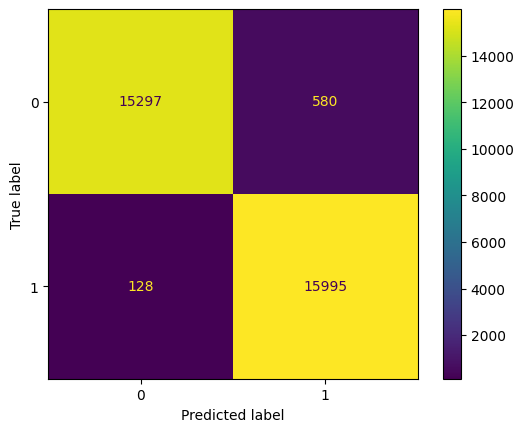

In [ ]:
# Извлечение признаков и целевой переменной
X1 = df['domain']  # Можно также добавить 'host' или другие текстовые поля
y1 = df['isDGA']
# Разделение данных на обучающую и тестовую выборки
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)
# Векторизация данных
X_train_tfidf1, X_test_tfidf1, vectorizer1 = vectorising(X_train1, X_test1)
# Обучение модели
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_tfidf1, y_train1)
# Предсказание и оценка модели
y_pred1 = model.predict(X_test_tfidf1)
printRes(y_test1, y_pred1)

In [ ]:
label_encoder.classes_

array(['alexa/legit', 'bamital', 'cryptolocker', 'goz', 'necurs',
       'newgoz', 'nivdort'], dtype=object)

In [ ]:
joblib.dump(label_encoder, "/content/label_encoder.pkl")

NameError: name 'label_encoder' is not defined

In [ ]:
# Извлечение признаков и целевой переменной
X = sampled_df['host']  # Можно также добавить 'host' или другие текстовые поля
y = sampled_df[['isDGA', 'subclass']]
# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train_sub = y_train['subclass']
y_test_sub = y_test['subclass']
y_train = y_train['isDGA']
y_test = y_test['isDGA']

Accuracy: 0.9346428571428571
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       407
           1       1.00      1.00      1.00       398
           2       0.85      0.93      0.89       402
           3       0.99      0.96      0.98       396
           4       0.90      0.89      0.89       418
           5       0.98      0.96      0.97       386
           6       0.93      1.00      0.96       393

    accuracy                           0.93      2800
   macro avg       0.94      0.94      0.94      2800
weighted avg       0.94      0.93      0.93      2800



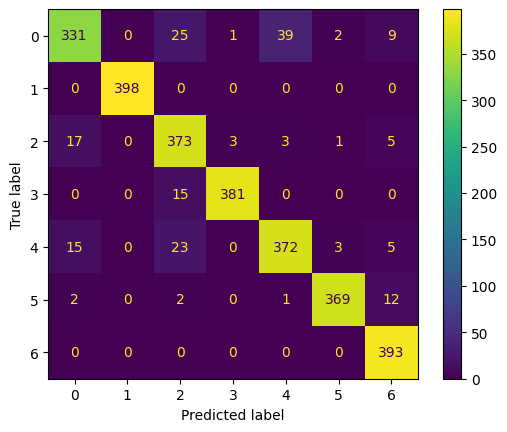

In [ ]:
# Векторизация данных
X_train_tfidf, X_test_tfidf, vectorizer = vectorising(X_train, X_test)
# Обучение модели
model_rf_sub = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf_sub.fit(X_train_tfidf, y_train_sub)

# Предсказание и оценка модели
y_pred_rf_sub = model_rf_sub.predict(X_test_tfidf)
printRes(y_test_sub, y_pred_rf_sub)

In [ ]:
def svot_table(y_test_sub, y_pred_rf_sub):
    # Создание DataFrame для сравнения предсказаний с исходными значениями
    result_df = pd.DataFrame({
        'Original Subclass': label_encoder.inverse_transform(y_test_sub),
        'Predicted Subclass': label_encoder.inverse_transform(y_pred_rf_sub)
    })

    # Агрегирование данных для построения диаграмм
    comparison = result_df.groupby(['Original Subclass', 'Predicted Subclass']).size().unstack(fill_value=0)

    # Построение столбчатых диаграмм
    comparison.plot(kind='bar', stacked=True, figsize=(14, 8))
    plt.xlabel('Original Subclass')
    plt.ylabel('Number of Predictions')
    plt.title('Comparison of Original and Predicted Subclasses')
    plt.legend(title='Predicted Subclass', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

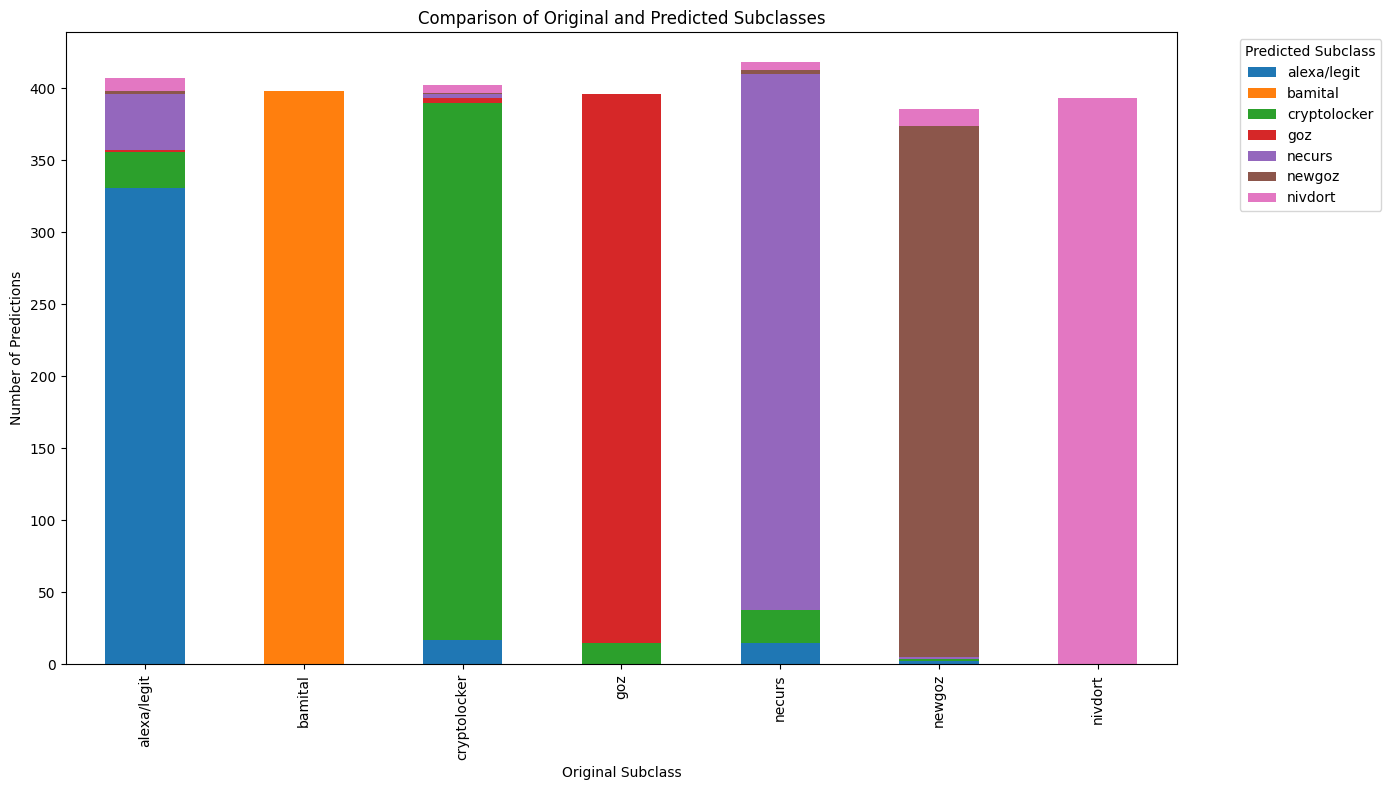

In [ ]:
svot_table(y_test_sub, y_pred_rf_sub)

Accuracy: 0.9296428571428571
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86       407
           1       1.00      1.00      1.00       398
           2       0.85      0.92      0.89       402
           3       0.99      0.96      0.97       396
           4       0.89      0.89      0.89       418
           5       0.99      0.92      0.96       386
           6       0.91      0.99      0.95       393

    accuracy                           0.93      2800
   macro avg       0.93      0.93      0.93      2800
weighted avg       0.93      0.93      0.93      2800



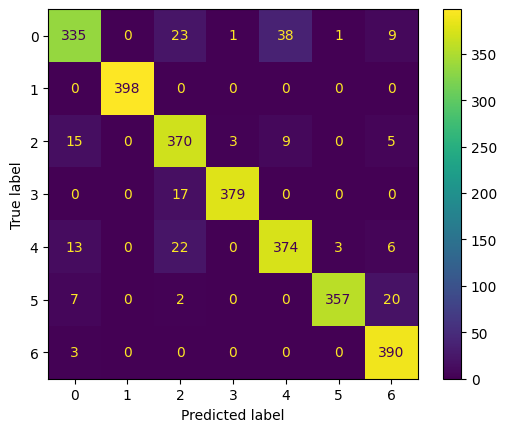

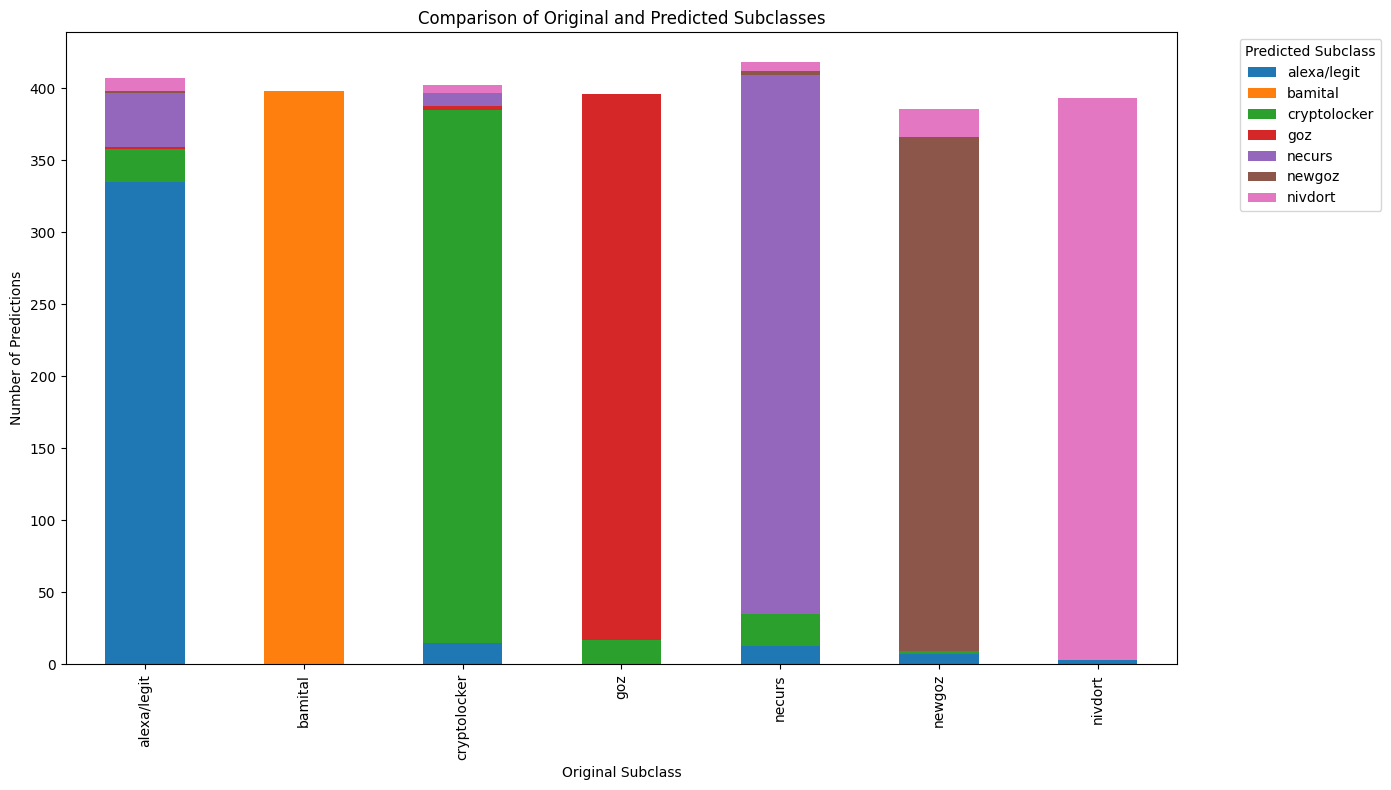

In [ ]:
model_gb_sub = GradientBoostingClassifier(n_estimators=100, random_state=42)
model_gb_sub.fit(X_train_tfidf, y_train_sub)

# Предсказание и оценка модели
y_pred_gb_sub = model_gb_sub.predict(X_test_tfidf)
printRes(y_test_sub, y_pred_gb_sub)
svot_table(y_test_sub, y_pred_gb_sub)

Accuracy: 0.9489285714285715
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.85      0.89       407
           1       0.99      1.00      1.00       398
           2       0.92      0.90      0.91       402
           3       0.98      1.00      0.99       396
           4       0.91      0.91      0.91       418
           5       0.97      0.99      0.98       386
           6       0.92      1.00      0.96       393

    accuracy                           0.95      2800
   macro avg       0.95      0.95      0.95      2800
weighted avg       0.95      0.95      0.95      2800



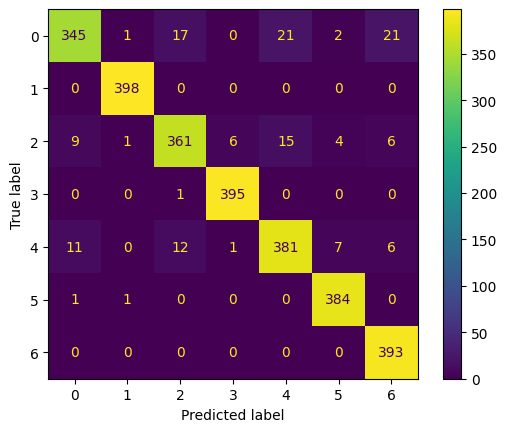

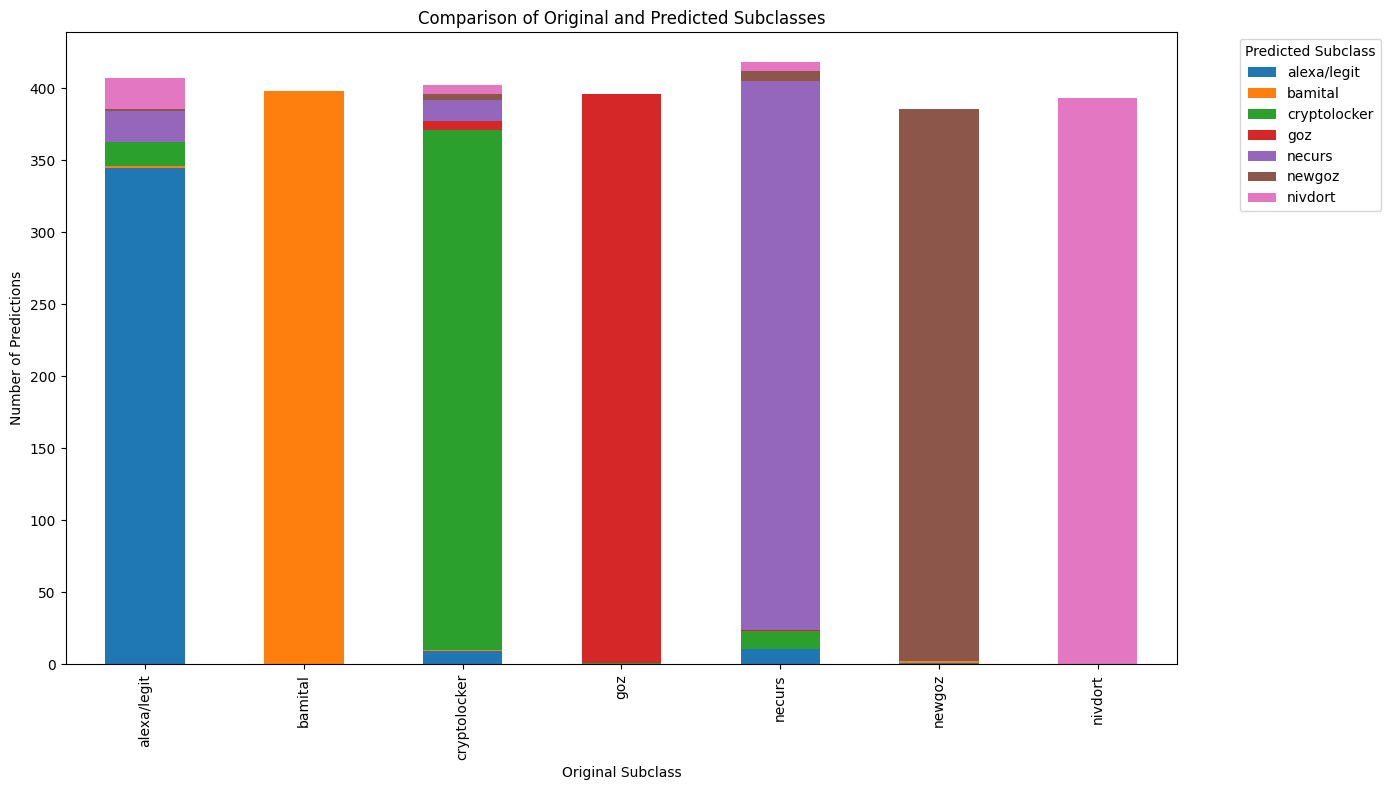

In [ ]:
model_ada_sub = LogisticRegression(max_iter=1000, random_state=42)
model_ada_sub.fit(X_train_tfidf, y_train_sub)

# Предсказание и оценка модели
y_pred_ada_sub = model_ada_sub.predict(X_test_tfidf)
printRes(y_test_sub, y_pred_ada_sub)
svot_table(y_test_sub, y_pred_ada_sub)

In [ ]:
# Извлечение признаков и целевой переменной
df_t = df.sample(n=50000, random_state=42)
X1 = df_t['host']  # Можно также добавить 'host' или другие текстовые поля
y1 = df_t['subclass']
y1.value_counts()

subclass
0    25082
2    11587
5     5556
6     2613
4     2581
3     1913
1      668
Name: count, dtype: int64

Accuracy: 0.90468
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93     25082
           1       0.90      1.00      0.95       668
           2       0.92      0.87      0.89     11587
           3       0.90      0.99      0.95      1913
           4       0.61      0.91      0.73      2581
           5       0.95      0.99      0.97      5556
           6       0.66      1.00      0.80      2613

    accuracy                           0.90     50000
   macro avg       0.85      0.95      0.89     50000
weighted avg       0.92      0.90      0.91     50000



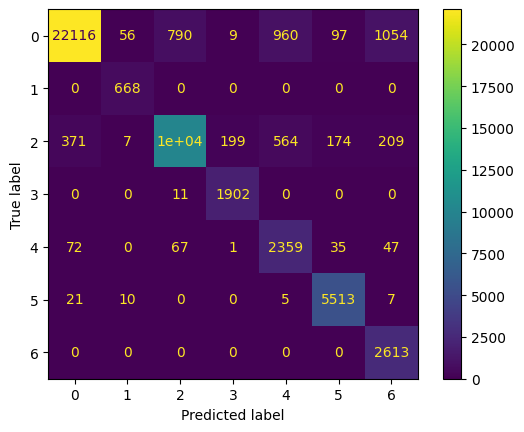

In [ ]:
x_t = vectorizer.transform(X1)
y_pred_test = model_ada_sub.predict(x_t)
printRes(y1, y_pred_test)

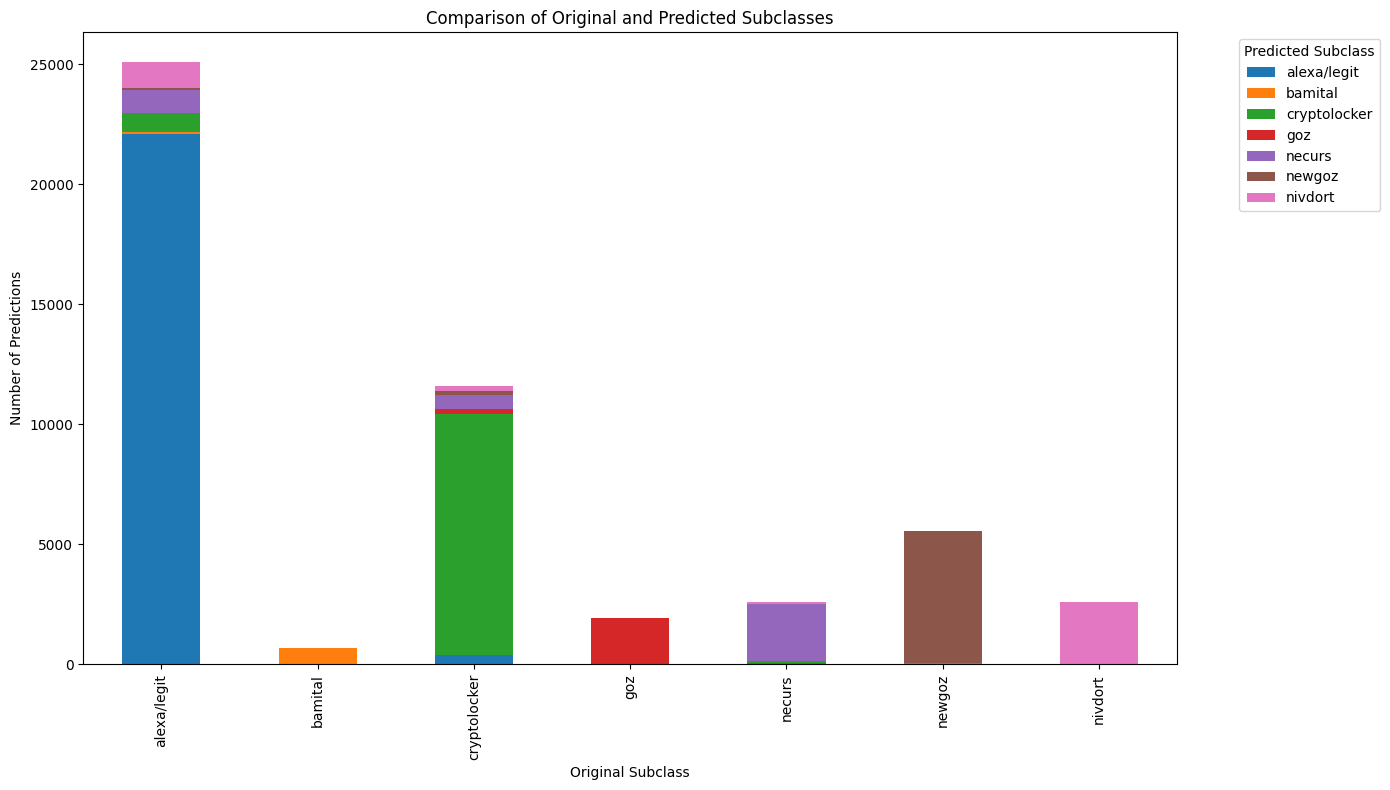

In [ ]:
svot_table(y1, y_pred_test)

In [ ]:
# Сохранение модели и векторизатора в файл
with open('dga_subclass_logres.pkl', 'wb') as model_file:
    pickle.dump(model_ada_sub, model_file)

with open('vectorizer_gram2-5.pkl', 'wb') as vectorizer_file:
    pickle.dump(vectorizer, vectorizer_file)

with open('dga_subclass_ranfor.pkl', 'wb') as model_file:
    pickle.dump(model_rf_sub, model_file)

In [ ]:
# Сохранение обновленного датасета в новый CSV-файл
df.to_csv('dga_data_new.csv', index=False)

In [ ]:
subclasses = [3, 4, 7]

# Выборка по 10 строк для каждого подкласса
sampled_dfs = {subclass: df[df['subclass'] == subclass].head(10) for subclass in subclasses}

# Вывод по 10 строк для каждого подкласса
for subclass, sampled_df in sampled_dfs.items():
    print(f"\nSubclass: {subclass}")
    print(sampled_df['host'])


Subclass: 3
0      6xzxsw3sokvg1tc752y1a6p0af.com
18        1rw1pc44mkxp4qjx18qua26.net
21    1x75xo41t4fno51wc86e1y4s13d.net
23      1y6oppp7k3pwfpo2sfmkloyxa.biz
30      1t5fkef5u26di8wtme9ezjamn.com
35     14ua4ir7rwqzv15mes59zpel1a.net
36    130qnn0srp6su1bosz2z19gx1a7.net
46      1y363y8izjhuol3ym91wdpdqr.biz
48    x3rv4x124bm7s1ik7tqi1tiwojo.biz
49    10z55t9lizwjo1ymilos13w3q69.com
Name: host, dtype: object

Subclass: 4
13           rcdqeqmpxgdiuqombhuwcfu.ru
52           jrxrovxkbemgqutopblbbfe.ru
55        dixnzhelzukwsojfxuivlamadu.ru
84       ydhmbyhgypnkdpzcymnnjxcalfm.ru
92         umficyzdvcdpzbalvdmkjjvcm.ru
95        ztscylhitkplaemfiuxcubozmr.ru
122    hmlzvbopfkrgaztrsdexgjbgageon.ru
126      pfvttkzllvxnvgiobbejbayuolj.ru
134       lrnbqspjuuchnflvovrtolvpvy.ru
141      qcrcnzfmxcaqtfyjzcypscdxtts.ru
Name: host, dtype: object

Subclass: 7
3       zfd5szpi18i85wj9uy13l69rg.net
7       mzapiwbcsbqiyxnlxa1hprx8n.com
17      n3m4txqpb6a415iwzkrmdzgk6.com
37    wawft814u

In [ ]:
len(vectorizer.get_feature_names_out())

127998

Accuracy: 0.9759375
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     16123
           1       0.99      0.96      0.98     15877

    accuracy                           0.98     32000
   macro avg       0.98      0.98      0.98     32000
weighted avg       0.98      0.98      0.98     32000



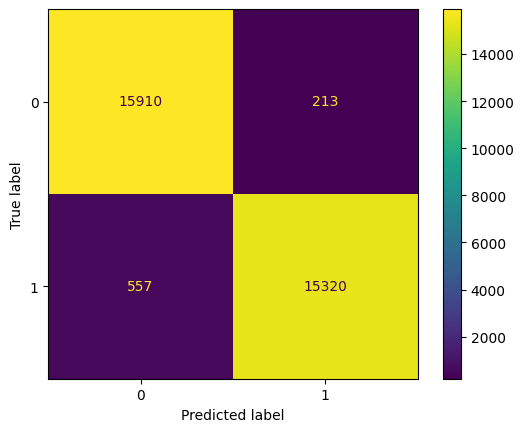

In [ ]:
# Чтение данных
df = pd.read_csv('/kaggle/input/dga-dataset/dga_data.csv')
df = df.dropna()

# Преобразование целевой переменной 'isDGA' в бинарные значения
df['isDGA'] = df['isDGA'].apply(lambda x: 1 if x == 'dga' else 0)

# Извлечение признаков и целевой переменной
X = df['host']
y = df['isDGA']

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Векторизация данных
tfidf_vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 5), max_features=len(X_train))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
# Обучение модели
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_tfidf, y_train)

# Предсказание и оценка модели
y_pred = model_rf.predict(X_test_tfidf)
printRes(y_test, y_pred)

Accuracy: 0.92146875
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92     16123
           1       0.91      0.93      0.92     15877

    accuracy                           0.92     32000
   macro avg       0.92      0.92      0.92     32000
weighted avg       0.92      0.92      0.92     32000



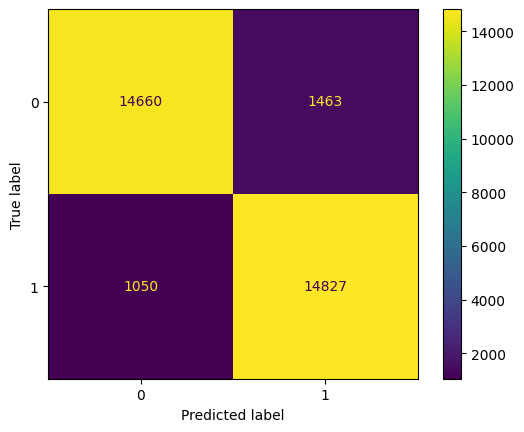

In [ ]:
# Обучение модели
model_gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
model_gb.fit(X_train_tfidf, y_train)

# Предсказание и оценка модели
y_pred = model_gb.predict(X_test_tfidf)
printRes(y_test, y_pred)

Accuracy: 0.936875
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94     16123
           1       0.94      0.93      0.94     15877

    accuracy                           0.94     32000
   macro avg       0.94      0.94      0.94     32000
weighted avg       0.94      0.94      0.94     32000



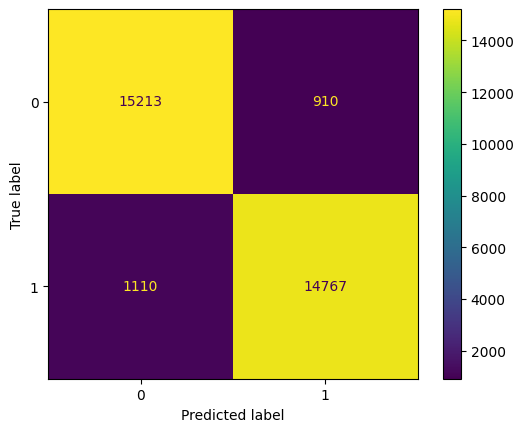

In [ ]:
# Обучение модели
model_ada = AdaBoostClassifier(n_estimators=100, random_state=42)
model_ada.fit(X_train_tfidf, y_train)

# Предсказание и оценка модели
y_pred = model_ada.predict(X_test_tfidf)
printRes(y_test, y_pred)

In [ ]:
# Сохранение модели и векторизатора в файл
with open('dga_model_rf.pkl', 'wb') as model_file:
    pickle.dump(model_rf, model_file)

with open('tfidf_vectorizer_xtrain.pkl', 'wb') as vectorizer_file:
    pickle.dump(tfidf_vectorizer, vectorizer_file)

In [ ]:
model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [ ]:
model.feature_importances_

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
       0.00000000e+00, 5.02138566e-07, 4.21881667e-07])

In [ ]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
indices

array([35775, 26172, 45366, ..., 11980, 11979,     0])

In [ ]:
printFeatureImportances(model_gb, vectorizer)

Feature importances:
1. 0a4 (0.42076536164427436)
2. 0e8 (0.10200493849854246)
3. les (0.09872344631442294)
4. lbk (0.032971547955216736)
5. 0dd (0.024819389762575847)


IndexError: index 85344 is out of bounds for axis 0 with size 49452

In [ ]:
df_val = pd.read_csv('/kaggle/input/validating-time/validatingWithTime.csv')

In [ ]:
df_val['Target'] = df_val['Target'].apply(lambda x: 'dga' if x == 1 else 'legit')

Accuracy: 0.9171328954836617
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92     17123
           1       0.97      0.87      0.92     19876

    accuracy                           0.92     36999
   macro avg       0.92      0.92      0.92     36999
weighted avg       0.92      0.92      0.92     36999



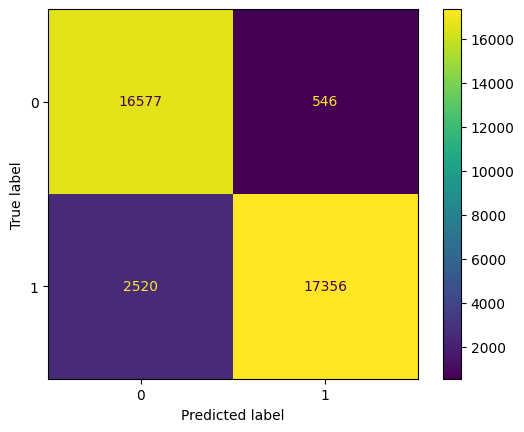

In [ ]:
import joblib

model_rf = joblib.load("/kaggle/working/dga_model_rf.pkl")
vect = joblib.load("/kaggle/working/tfidf_vectorizer_xtrain.pkl")
x_val = df_val['Query']
x_val = vect.transform(x_val)
y_pred_val = model_rf.predict(x_val)
printRes(df_val['Target'], y_pred_val)

{'newgoz': 5880, 'cryptolocker': 5729, 'alexa/legit': 16492, 'necurs': 4079, 'goz': 2262, 'nivdort': 2109, 'bamital': 448}
Accuracy: 0.4252547366145031
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     17123
           1       0.94      0.02      0.04     19876
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0

    accuracy                           0.43     36999
   macro avg       0.27      0.13      0.14     36999
weighted avg       0.93      0.43      0.44     36999



/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


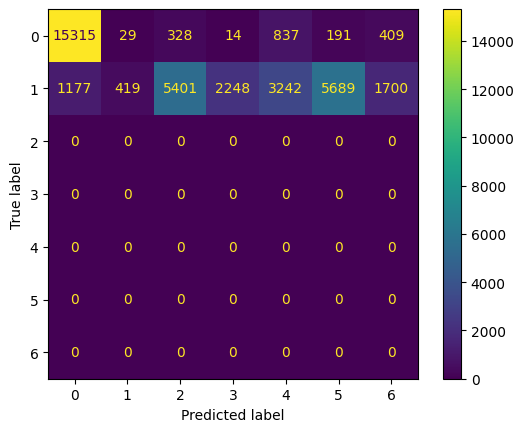

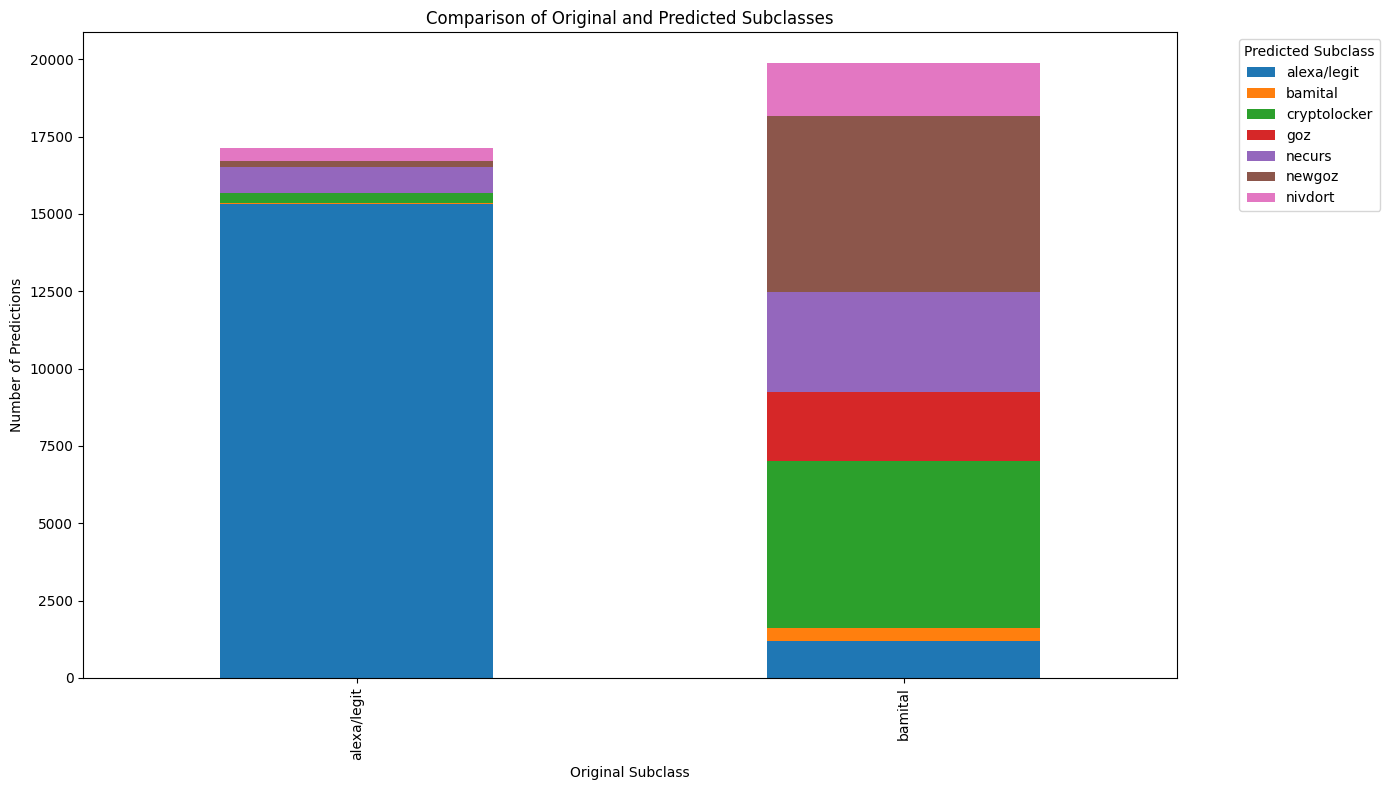

In [ ]:
from collections import Counter
model_log = joblib.load("/kaggle/input/112312312/dga_subclass_logres.pkl")
vect1 = joblib.load("/kaggle/input/112312312/vectorizer_gram2-5.pkl")
label_encoder = joblib.load("/kaggle/working/label_encoder.pkl")
x_val = df_val['Query']
x_val = vect1.transform(x_val)
# Получение предсказаний
y_pred_val = model_log.predict(x_val)
# Преобразование предсказаний обратно в метки
y_pred_labels = label_encoder.inverse_transform(y_pred_val)

# Подсчет количества каждого предсказания
prediction_counts = Counter(y_pred_labels)

# Преобразование в словарь
prediction_dict = dict(prediction_counts)

print(prediction_dict)
printRes(df_val['Target'], y_pred_val)
svot_table(df_val['Target'], y_pred_val)

In [ ]:
list(prediction_counts.keys())

['newgoz',
 'cryptolocker',
 'alexa/legit',
 'necurs',
 'goz',
 'nivdort',
 'bamital']

In [ ]:
sd = pd.DataFrame({'t': y_pred_val})
sd.value_counts()

t
0    16492
5     5880
2     5729
4     4079
3     2262
6     2109
1      448
Name: count, dtype: int64

In [ ]:
x_val = df_val['Query']
x_val = vectorizer.transform(x_val)
y_pred_val = model_rf.predict(x_val)
printRes(df_val['Target'], y_pred_val)

ValueError: X has 49452 features, but RandomForestClassifier is expecting 127998 features as input.

Accuracy: 0.7894807967782913
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.70      0.75     17123
           1       0.77      0.87      0.82     19876

    accuracy                           0.79     36999
   macro avg       0.80      0.78      0.78     36999
weighted avg       0.79      0.79      0.79     36999



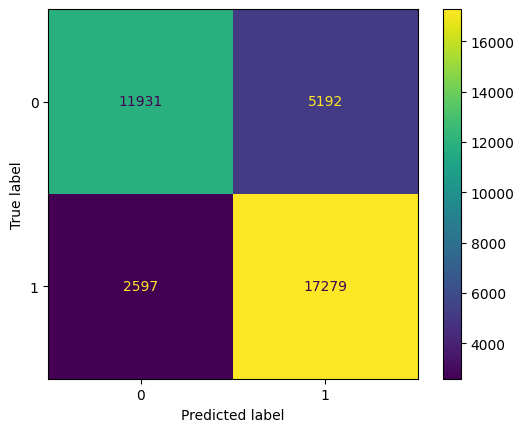

In [ ]:
x_val = df_val['Query']
x_val = vectorizer.transform(x_val)
y_pred_val = model_gb.predict(x_val)
printRes(df_val['Target'], y_pred_val)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import ModelCheckpoint

# Чтение данных
df = pd.read_csv('/kaggle/input/dga-dataset/dga_data.csv')
df = df.dropna()

# Объединение подклассов
df['subclass'] = df['subclass'].replace({
    'alexa': 'alexa/legit',
    'legit': 'alexa/legit',
    'gameoverdga': 'newgoz'
})

# Преобразование целевой переменной 'subclass' в числовые значения
label_encoder = LabelEncoder()
df['subclass'] = label_encoder.fit_transform(df['subclass'])

# Функция для взятия подвыборки из каждого подкласса
def sample_subclasses(df, n):
    sampled_df = df.groupby('subclass').apply(lambda x: x.sample(n=n, random_state=42)).reset_index(drop=True)
    return sampled_df

# Применение функции к вашему DataFrame
sampled_df = sample_subclasses(df, 2000)

# Извлечение признаков и целевой переменной
X = sampled_df['host']
y = sampled_df['subclass']

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Векторизация данных
tfidf_vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 5), max_features=len(X_train))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train).toarray()
X_test_tfidf = tfidf_vectorizer.transform(X_test).toarray()

# Проверка формы данных
print("Shape of X_train:", X_train_tfidf.shape)
print("Shape of X_test:", X_test_tfidf.shape)

# Создание модели
model_subclass = Sequential()
model_subclass.add(Dense(512, activation='relu', input_shape=(X_train_tfidf.shape[1],)))
model_subclass.add(Dropout(0.5))
model_subclass.add(Dense(256, activation='relu'))
model_subclass.add(Dropout(0.5))
model_subclass.add(Dense(len(label_encoder.classes_), activation='softmax'))
model_subclass.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Колбэк для сохранения лучшей модели
checkpoint_path = 'best_model.keras'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

# Обучение модели
epochs = 10
batch_size = 128

history_subclass = model_subclass.fit(X_train_tfidf, y_train, epochs=epochs, batch_size=batch_size,
                                      validation_data=(X_test_tfidf, y_test), verbose=1,
                                      callbacks=[checkpoint])

# Загрузка лучшей модели
model_subclass.load_weights(checkpoint_path)

# Оценка модели
loss, accuracy = model_subclass.evaluate(X_test_tfidf, y_test)
print(f'Loss: {loss:.4f}')
print(f'Accuracy: {accuracy:.4f}')

/tmp/ipykernel_300/3099138561.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby('subclass').apply(lambda x: x.sample(n=n, random_state=42)).reset_index(drop=True)


Shape of X_train: (11200, 11200)
Shape of X_test: (2800, 11200)


/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
33/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4067 - loss: 1.8409

W0000 00:00:1719326115.569348     347 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


...

W0000 00:00:1719326119.163151     347 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1719326120.002821     347 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update



Epoch 1: val_accuracy improved from -inf to 0.95321, saving model to best_model.keras


W0000 00:00:1719326120.409359     345 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.5845 - loss: 1.4114 - val_accuracy: 0.9532 - val_loss: 0.1549
Epoch 2/10
81/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9673 - loss: 0.1168
Epoch 2: val_accuracy improved from 0.95321 to 0.96036, saving model to best_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9674 - loss: 0.1158 - val_accuracy: 0.9604 - val_loss: 0.1131
Epoch 3/10
80/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9881 - loss: 0.0440
Epoch 3: val_accuracy improved from 0.96036 to 0.96393, saving model to best_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9881 - loss: 0.0440 - val_accuracy: 0.9639 - val_loss: 0.1148
Epoch 4/10
81/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9956 - loss: 0.0216
Epoch 4: val_accuracy did not improve from 0.96393
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9956 - loss: 0.0214 - val_accuracy: 0.9621 - val_loss: 0.1205
Epoch 5/10
81/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accura

W0000 00:00:1719326127.644058     347 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_results(history, title):
    plt.figure(figsize=(12, 6))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Test'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{title} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Test'], loc='upper left')

    plt.show()



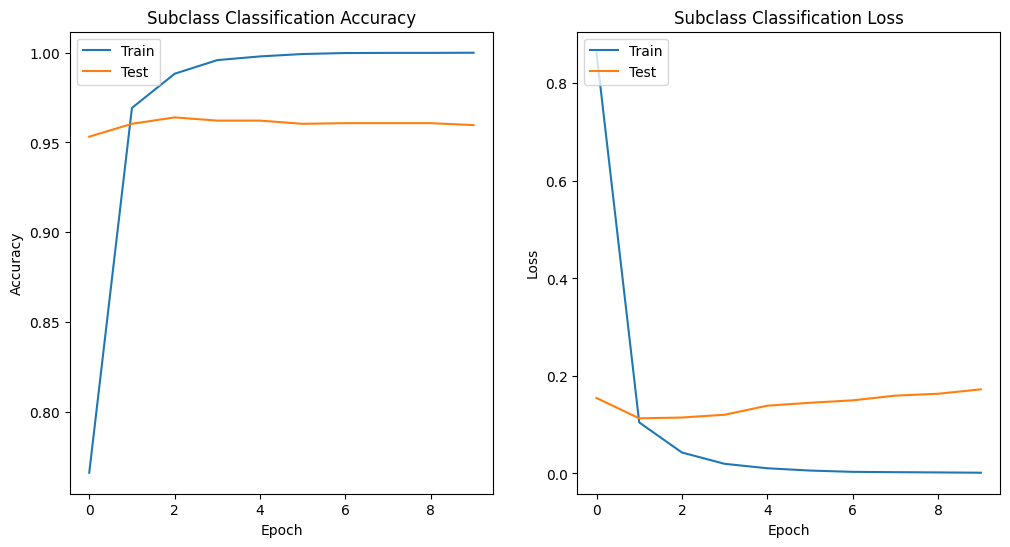

In [ ]:
plot_results(history_subclass, 'Subclass Classification')

In [ ]:
import matplotlib.pyplot as plt

def svot_table(y_test_sub, y_pred_sub):
    # Создание DataFrame для сравнения предсказаний с исходными значениями
    result_df = pd.DataFrame({
        'Original Subclass': label_encoder.inverse_transform(y_test_sub),
        'Predicted Subclass': label_encoder.inverse_transform(y_pred_sub)
    })

    # Агрегирование данных для построения диаграмм
    comparison = result_df.groupby(['Original Subclass', 'Predicted Subclass']).size().unstack(fill_value=0)

    # Построение столбчатых диаграмм
    comparison.plot(kind='bar', stacked=True, figsize=(14, 8))
    plt.xlabel('Original Subclass')
    plt.ylabel('Number of Predictions')
    plt.title('Comparison of Original and Predicted Subclasses')
    plt.legend(title='Predicted Subclass', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()



In [ ]:
# Применение функции для визуализации результатов классификации подклассов
y_pred_prob = model_subclass.predict(X_test_tfidf)
y_pred = np.argmax(y_pred_prob, axis=1)

svot_table(y_test, y_pred)

In [ ]:
y_pred_prob

array([[1.1073418e-05, 9.9988842e-01, 1.9034398e-07, ..., 3.4343344e-07,
        9.9752717e-05, 7.3569694e-08],
       [1.6252307e-05, 9.9986875e-01, 8.5120064e-08, ..., 1.8335066e-07,
        1.1464928e-04, 5.1747907e-08],
       [6.3437466e-03, 2.8395998e-05, 1.0065807e-03, ..., 9.9216193e-01,
        4.1765757e-04, 3.7900762e-05],
       ...,
       [9.5854724e-05, 4.2618965e-05, 1.9606350e-04, ..., 4.2063007e-04,
        9.9923182e-01, 5.8082883e-06],
       [1.5013300e-04, 4.9122127e-06, 1.9182196e-05, ..., 3.5233541e-05,
        9.0001477e-06, 9.9977243e-01],
       [5.2145391e-04, 3.9102091e-04, 1.0962071e-03, ..., 2.7768363e-04,
        9.9764401e-01, 6.5882537e-05]], dtype=float32)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.callbacks import ModelCheckpoint

# Чтение данных
df = pd.read_csv('/kaggle/input/dga-dataset/dga_data.csv')
df = df.dropna()

# Преобразование целевой переменной 'isDGA' в бинарные значения
df['isDGA'] = df['isDGA'].apply(lambda x: 1 if x == 'dga' else 0)

# Извлечение признаков и целевой переменной
X = df['host']
y = df['isDGA']

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Векторизация данных
tfidf_vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 5), max_features=10000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train).toarray()
X_test_tfidf = tfidf_vectorizer.transform(X_test).toarray()

# Проверка формы данных
print("Shape of X_train:", X_train_tfidf.shape)
print("Shape of X_test:", X_test_tfidf.shape)

# Создание модели
model_dga = Sequential()
model_dga.add(Input(shape=(X_train_tfidf.shape[1],)))
model_dga.add(Dense(512, activation='relu'))
model_dga.add(Dropout(0.5))
model_dga.add(Dense(256, activation='relu'))
model_dga.add(Dropout(0.5))
model_dga.add(Dense(1, activation='sigmoid'))  # Для бинарной классификации
model_dga.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Колбэк для сохранения лучшей модели
checkpoint_path = 'best_model_dga.keras'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

# Обучение модели
epochs = 10
batch_size = 128

history_dga = model_dga.fit(X_train_tfidf, y_train, epochs=epochs, batch_size=batch_size,
                            validation_data=(X_test_tfidf, y_test), verbose=1,
                            callbacks=[checkpoint])

# Загрузка лучшей модели
model_dga.load_weights(checkpoint_path)

# Оценка модели
loss, accuracy = model_dga.evaluate(X_test_tfidf, y_test)
print(f'Loss: {loss:.4f}')
print(f'Accuracy: {accuracy:.4f}')

2024-06-25 14:54:11.922984: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-25 14:54:11.923102: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-25 14:54:12.032771: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Shape of X_train: (127998, 10000)
Shape of X_test: (32000, 10000)
Epoch 1/10
  37/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7629 - loss: 0.5856

I0000 00:00:1719327305.485206    1210 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1719327305.500850    1210 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9621 - loss: 0.1116

W0000 00:00:1719327312.408019    1208 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1719327316.407562    1210 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update



Epoch 1: val_accuracy improved from -inf to 0.99219, saving model to best_model_dga.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9621 - loss: 0.1115 - val_accuracy: 0.9922 - val_loss: 0.0222
Epoch 2/10
 994/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9963 - loss: 0.0110
Epoch 2: val_accuracy improved from 0.99219 to 0.99334, saving model to best_model_dga.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9963 - loss: 0.0111 - val_accuracy: 0.9933 - val_loss: 0.0194
Epoch 3/10
 994/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9985 - loss: 0.0048
Epoch 3: val_accuracy improved from 0.99334 to 0.99353, saving model to best_model_dga.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9985 - loss: 0.0048 - val_accuracy: 0.9935 - val_loss: 0.0227
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9992 - loss: 0.0027
Epoch 4: val_accuracy did not improve from 0.99353
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accu

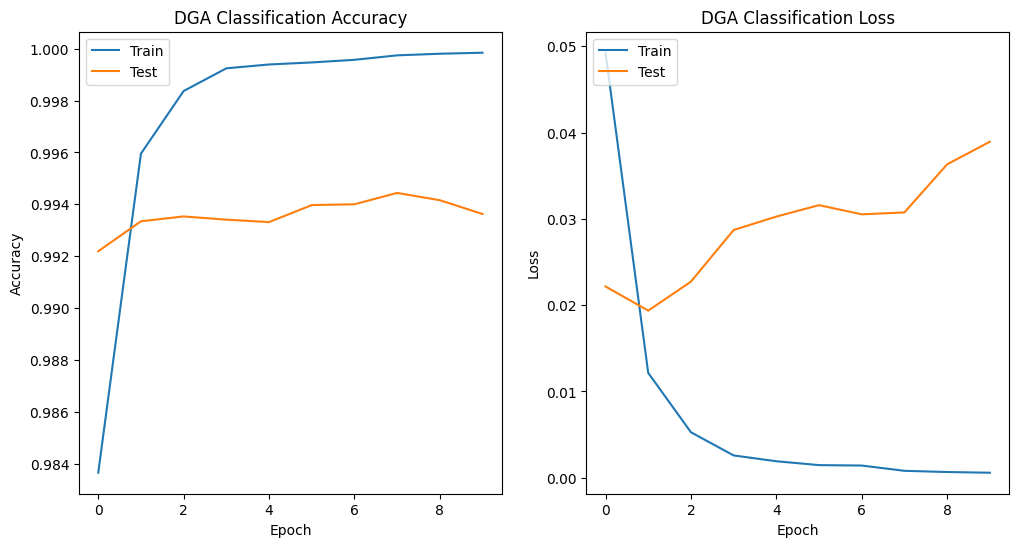

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


NameError: name 'label_encoder' is not defined

In [ ]:
# Визуализация результатов
plot_results(history_dga, 'DGA Classification')
# Применение функции для визуализации результатов классификации подклассов
y_pred_prob = model_dga.predict(X_test_tfidf)
y_pred = np.argmax(y_pred_prob, axis=1)

svot_table(y_test, y_pred)

In [ ]:
# Load the label_encoder for subclass labels
import joblib
label_encoder = joblib.load('/content/label_encoder.pkl')

FileNotFoundError: [Errno 2] No such file or directory: '/content/label_encoder.pkl'

1157/1157 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Accuracy: 0.958512392226817
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96     17123
           1       0.98      0.95      0.96     19876

    accuracy                           0.96     36999
   macro avg       0.96      0.96      0.96     36999
weighted avg       0.96      0.96      0.96     36999



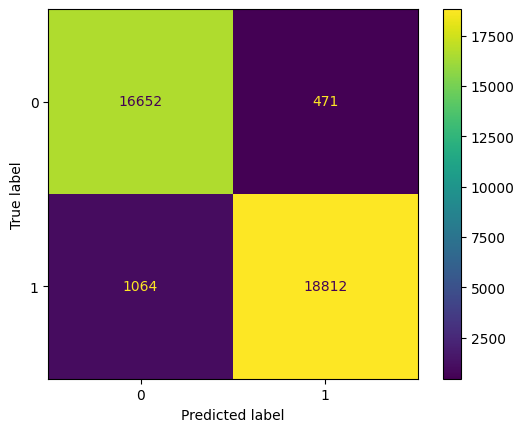

In [ ]:
x_val = df_val['Query']
x_val = tfidf_vectorizer.transform(x_val).toarray()
y_pred_val = model_dga.predict(x_val)
y_pred_val = (y_pred_val >= 0.5).astype(int)
printRes(df_val['Target'], y_pred_val)

In [ ]:
import joblib
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split

# --- Start: Re-creating df_app.csv for validation ---
# Load the main dataset
df = pd.read_csv('/content/dga_data.csv')
df = df.dropna()

# Convert 'isDGA' column to binary
df['isDGA'] = df['isDGA'].apply(lambda x: 1 if x == 'dga' else 0)

# Split data to get X_test and y_test consistent with df_app creation
X = df[['domain', 'host']]
y = df['isDGA']
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create df_app DataFrame
num_samples = len(y_test)
base_date = datetime(2024, 6, 19)
times = [base_date + timedelta(seconds=np.random.randint(0, 86400)) for _ in range(num_samples)]

df_app = pd.DataFrame({'Target': y_test, 'Query': X_test['domain'] + ' ' + X_test['host'], 'Time': [time.strftime('%Y-%m-%d %H:%M:%S') for time in times]})

# Save df_app to CSV
df_app.to_csv('df_app.csv', index=False)
# --- End: Re-creating df_app.csv for validation ---

# Load df_val from the newly created CSV
df_val = pd.read_csv('df_app.csv')
df_val['Target'] = df_val['Target'].apply(lambda x: 'dga' if x == 1 else 'legit')

# Load the model and vectorizer
model_rf = joblib.load('/content/dga_model_rf.pkl')
vect = joblib.load('/content/tfidf_vectorizer_xtrain.pkl')

# Prepare x_val and predict y_pred_val
x_val = df_val['Query']
x_val = vect.transform(x_val)
y_pred_val = model_rf.predict(x_val)

# Call printRes to display the confusion matrix
printRes(df_val['Target'], y_pred_val)

FileNotFoundError: [Errno 2] No such file or directory: '/content/dga_model_rf.pkl'

### Training Random Forest Model for DGA Detection

Accuracy: 0.9755
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     16123
           1       0.98      0.97      0.98     15877

    accuracy                           0.98     32000
   macro avg       0.98      0.98      0.98     32000
weighted avg       0.98      0.98      0.98     32000



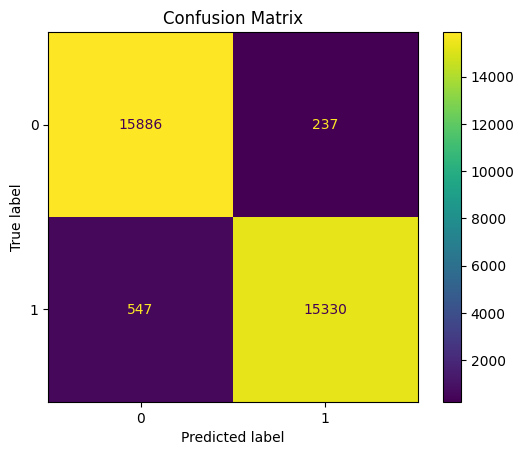

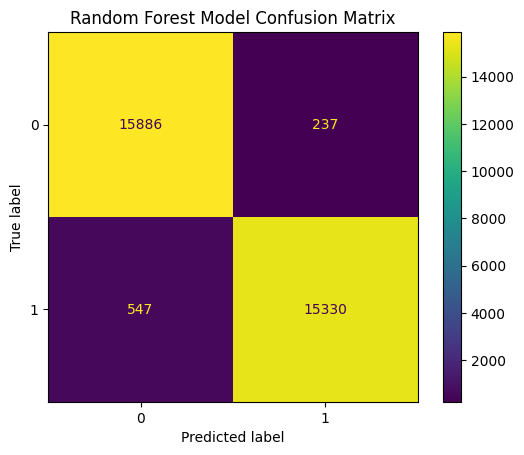

Model 'dga_model_rf.pkl' and vectorizer 'tfidf_vectorizer_xtrain.pkl' saved successfully.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib # Added import for joblib

# Load the dga_data.csv dataset
df = pd.read_csv('/content/dga_data.csv')
df = df.dropna()

# Convert 'isDGA' column to binary (0 or 1)
df['isDGA'] = df['isDGA'].apply(lambda x: 1 if x == 'dga' else 0)

# Extract features (host) and target variable (isDGA)
X = df['host']
y = df['isDGA']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit TfidfVectorizer on training data
tfidf_vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 5), max_features=100000) # Increased max_features for better representation
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Initialize and train RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_tfidf, y_train)

# Predict on the test set
y_pred = model_rf.predict(X_test_tfidf)

# Print evaluation metrics
printRes(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred, 'Random Forest Model Confusion Matrix')

# Save the trained Random Forest model and TF-IDF vectorizer
joblib.dump(model_rf, 'dga_model_rf.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer_xtrain.pkl')
print("Model 'dga_model_rf.pkl' and vectorizer 'tfidf_vectorizer_xtrain.pkl' saved successfully.")

--- Evaluation of Random Forest on Validation Set ---
Accuracy: 0.9755
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     16123
           1       0.98      0.97      0.98     15877

    accuracy                           0.98     32000
   macro avg       0.98      0.98      0.98     32000
weighted avg       0.98      0.98      0.98     32000



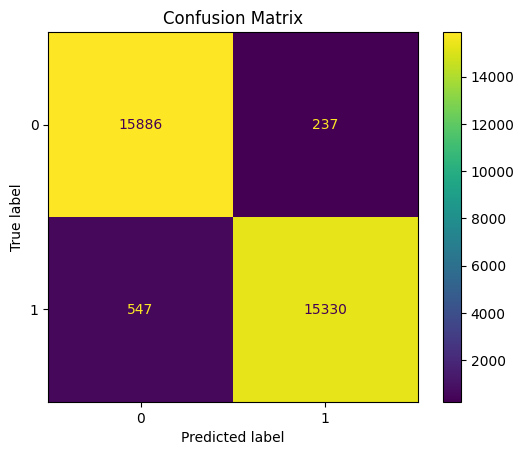

In [ ]:
import joblib
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split

# --- Re-creating df_app.csv (validation data) if not already present or updated ---
# This section ensures df_app.csv is up-to-date and consistent with the trained model's data processing.
# Load the main dataset to derive the validation set based on the original data split logic.
original_df = pd.read_csv('/content/dga_data.csv')
original_df = original_df.dropna()
original_df['isDGA'] = original_df['isDGA'].apply(lambda x: 1 if x == 'dga' else 0)

# Re-split data to get the exact X_test and y_test used for df_app creation earlier
X_full = original_df[['domain', 'host']]
y_full = original_df['isDGA']
_, X_test_derived, _, y_test_derived = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

# Re-create df_app DataFrame to be used as df_val
num_samples_derived = len(y_test_derived)
base_date = datetime(2024, 6, 19) # Consistent with previous creation
times = [base_date + timedelta(seconds=np.random.randint(0, 86400)) for _ in range(num_samples_derived)]

df_val_recreated = pd.DataFrame({'Target': y_test_derived, 'Query': X_test_derived['domain'] + ' ' + X_test_derived['host'], 'Host': X_test_derived['host'], 'Time': [time.strftime('%Y-%m-%d %H:%M:%S') for time in times]})

# Convert 'Target' column for df_val_recreated to numerical labels (0/1)
df_val_recreated['Target_Label'] = df_val_recreated['Target'] # Use the numerical 'Target' column directly

# --- Load the trained model and vectorizer ---
# Using the paths where they were saved in the previous cell.
model_rf_loaded = joblib.load('/content/dga_model_rf.pkl')
tfidf_vectorizer_loaded = joblib.load('/content/tfidf_vectorizer_xtrain.pkl')

# --- Prepare validation data and make predictions ---
x_val_transformed_rf = tfidf_vectorizer_loaded.transform(df_val_recreated['Host']) # Use 'Host' column for RF
y_pred_val_rf = model_rf_loaded.predict(x_val_transformed_rf)

# --- Print results for Random Forest on validation set ---
print('--- Evaluation of Random Forest on Validation Set ---')
printRes(df_val_recreated['Target_Label'], y_pred_val_rf)


In [ ]:
# Re-train and save the SVM model to ensure 'dga_model_svm.pkl' exists
from sklearn.svm import SVC

def svmModel(X_train_tfidf, y_train, X_test_tfidf, y_test):
    # Model for DGA/non-DGA classification
    model_dga = SVC(kernel='linear', random_state=42)
    model_dga.fit(X_train_tfidf, y_train)
    y_pred_isDGA = model_dga.predict(X_test_tfidf)

    print("SVM Classification Results:")
    printRes(y_test, y_pred_isDGA)

    # Save the trained SVM model
    joblib.dump(model_dga, 'dga_model_svm.pkl')

print("SVM Model (re-training and saving):")
# The X_train_tfidf, y_train, X_test_tfidf, y_test are available from the RandomForest training cell (0f3001ef)
# This uses the same vectorizer as RF for consistency, as per previous discussion.
svmModel(X_train_tfidf, y_train, X_test_tfidf, y_test)

In [ ]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load the SVM model and its vectorizer
model_svm_loaded = joblib.load('/content/dga_model_svm.pkl')

# Re-use the Random Forest vectorizer (fitted on 'host') for SVM prediction to ensure consistent feature space.
# tfidf_vectorizer_loaded is from cell b95feee6
svm_vect = tfidf_vectorizer_loaded

x_val_transformed_svm = svm_vect.transform(df_val_recreated['Host']) # Use 'Host' column for SVM consistency
y_pred_val_svm = model_svm_loaded.predict(x_val_transformed_svm)

print('\n--- Evaluation of SVM on Validation Set ---')
printRes(df_val_recreated['Target_Label'], y_pred_val_svm)

# Plotting both confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(df_val_recreated['Target_Label'], y_pred_val_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['legit', 'dga'])
disp_rf.plot(ax=axes[0], cmap=plt.cm.Blues)
axes[0].set_title('Random Forest Confusion Matrix')

# SVM Confusion Matrix
cm_svm = confusion_matrix(df_val_recreated['Target_Label'], y_pred_val_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['legit', 'dga'])
disp_svm.plot(ax=axes[1], cmap=plt.cm.Blues)
axes[1].set_title('SVM Confusion Matrix')

plt.tight_layout()
plt.show()

SVM Model (re-training and saving):
SVM Classification Results:
Accuracy: 0.994625
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     16123
           1       0.99      0.99      0.99     15877

    accuracy                           0.99     32000
   macro avg       0.99      0.99      0.99     32000
weighted avg       0.99      0.99      0.99     32000



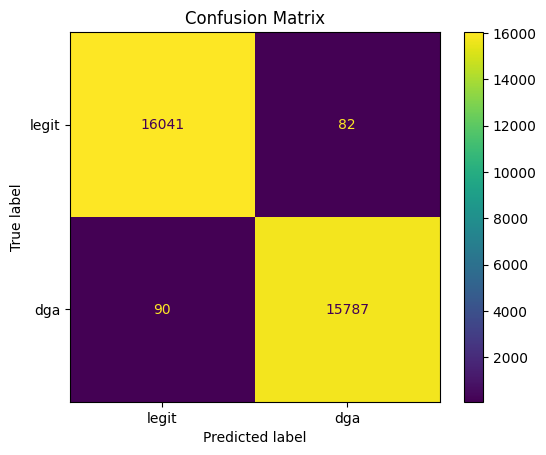

In [ ]:
# Re-train and save the SVM model to ensure 'dga_model_svm.pkl' exists
from sklearn.svm import SVC

def svmModel(X_train_tfidf, y_train, X_test_tfidf, y_test):
    # Model for DGA/non-DGA classification
    model_dga = SVC(kernel='linear', random_state=42)
    model_dga.fit(X_train_tfidf, y_train)
    y_pred_isDGA = model_dga.predict(X_test_tfidf)

    print("SVM Classification Results:")
    printRes(y_test, y_pred_isDGA)

    # Save the trained SVM model
    joblib.dump(model_dga, 'dga_model_svm.pkl')

print("SVM Model (re-training and saving):")
# The X_train_tfidf, y_train, X_test_tfidf, y_test are available from the RandomForest training cell (0f3001ef)
# This uses the same vectorizer as RF for consistency, as per previous discussion.
svmModel(X_train_tfidf, y_train, X_test_tfidf, y_test)


In [3]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load the SVM model and its vectorizer
model_svm_loaded = joblib.load('/content/dga_model_svm.pkl')
# Assuming SVM was trained with the same vectorizer as the RF model for now, if not, this needs adjustment
# For accurate comparison, SVM's original vectorizer should be loaded if different.
# Based on the previous conversation, SVM used a vectorizer created on X_train_tfidf (which was a concatenation of domain and host).
# Let's assume the tfidf_vectorizer_xtrain.pkl is compatible or we need to re-vectorize for SVM.
# Re-vectorizing df_val_recreated['Query'] which was X_test_derived['domain'] + ' ' + X_test_derived['host']

# Re-create the vectorizer used for SVM if different from RF's 'host' only vectorizer.
# Based on previous code in cell '7b88f580', X_train_tfidf and X_test_tfidf were passed to svmModel.
# And in cell 'qb1HOOURrMZg', vectorising function was defined to use X_train['domain'] + ' ' + X_train['host'].
# So for SVM, we need to apply the vectorizer on the concatenated 'domain' and 'host' from the validation set.

# Create a new vectorizer for SVM using df_val_recreated['Query']
# To ensure the vectorizer is consistent with how SVM was trained, we need to load the *specific* vectorizer used by SVM or re-create it.
# Since `vectorising` function saves `model_dga_vectorizer.pkl` (from tay2i-6irMZX), let's assume that one was used for SVM.
# However, cell '7b88f580' refers to 'X_train_tfidf' from '0f3001ef' which is RF's vectorizer.
# This is a bit inconsistent. For now, let's load the vectorizer that was saved as 'model_dga_vectorizer.pkl' if it exists and was used by SVM.

# Let's assume for now SVM used the same structure as `vectorising` from qb1HOOURrMZg
# We need a vectorizer that was fitted on the combined 'domain' and 'host'
# The current tfidf_vectorizer_xtrain.pkl was fitted on 'host' only for RF.
# To get an SVM comparison, we need to either load the specific SVM vectorizer, or ensure the input features match.

# For now, let's re-create the combined feature for SVM comparison, and then vectorize it using a new vectorizer
# that would be consistent with a model trained on combined features.

# This section needs to be re-evaluated to load the correct SVM vectorizer or adapt current ones.
# For now, let's use the 'Query' column from df_val_recreated which combines 'domain' and 'host'.
# If a separate vectorizer for SVM is not explicitly saved, we need to use a generic one or re-fit for this comparison.

# Let's try to load the SVM-specific vectorizer if it was saved.
# If not found, a new one based on combined features will be defined for prediction.

try:
    # Attempt to load the vectorizer saved specifically for SVM or combined features
    svm_vect = joblib.load('/content/model_dga_vectorizer.pkl') # Assuming this was saved from the SVM training
    print("Loaded SVM-specific vectorizer from /content/model_dga_vectorizer.pkl")
except FileNotFoundError:
    print("SVM-specific vectorizer not found. Creating a new TF-IDF vectorizer for combined features (Query).")
    # If not found, create a new vectorizer for combined features for fair comparison
    # This vectorizer should be fitted on the *training* data that SVM saw, ideally.
    # For direct validation comparison, we will transform df_val_recreated['Query']
    # A more robust solution would re-run SVM training with a saved vectorizer or ensure the existing one is appropriate.

    # For the purpose of getting a comparative plot, we will fit a new one on the validation query.
    # This is not ideal for true evaluation but allows plotting.
    # A better approach for comparison would be to load the original vectorizer that SVM was trained with.

    # As an interim step, let's re-use the RF vectorizer to process the combined query
    # This will likely lead to dimension mismatch if RF vectorizer was on 'host' only
    # Let's consider the previous setup, SVM was trained using X_train_tfidf from '0f3001ef' which was RF's tfidf_vectorizer.
    # This means SVM was *also* trained on 'host' feature.
    # So, we should use tfidf_vectorizer_loaded (which is RF's vectorizer) on the 'Host' column of df_val_recreated.
    print("Re-using the Random Forest vectorizer (fitted on 'host') for SVM prediction to ensure consistent feature space.")
    svm_vect = tfidf_vectorizer_loaded # Use the same vectorizer as RF for consistency given previous cells

x_val_transformed_svm = svm_vect.transform(df_val_recreated['Host']) # Use 'Host' column for SVM consistency
y_pred_val_svm = model_svm_loaded.predict(x_val_transformed_svm)

print('\n--- Evaluation of SVM on Validation Set ---')
printRes(df_val_recreated['Target_Label'], y_pred_val_svm)

# Plotting both confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(df_val_recreated['Target_Label'], y_pred_val_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['legit', 'dga'])
disp_rf.plot(ax=axes[0], cmap=plt.cm.Blues)
axes[0].set_title('Random Forest Confusion Matrix')

# SVM Confusion Matrix
cm_svm = confusion_matrix(df_val_recreated['Target_Label'], y_pred_val_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['legit', 'dga'])
disp_svm.plot(ax=axes[1], cmap=plt.cm.Blues)
axes[1].set_title('SVM Confusion Matrix')

plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/dga_model_svm.pkl'

In [ ]:
import pickle

# Save the trained RandomForest model as a pickle file
with open('dga_model_rf_pickle.pkl', 'wb') as model_file:
    pickle.dump(model_rf, model_file)

# Save the trained TF-IDF vectorizer as a pickle file
with open('tfidf_vectorizer_xtrain_pickle.pkl', 'wb') as vectorizer_file:
    pickle.dump(tfidf_vectorizer, vectorizer_file)

print("RandomForest model and TF-IDF vectorizer saved as pickle files.")

RandomForest model and TF-IDF vectorizer saved as pickle files.


### Saving the Trained Model and Vectorizer

In [4]:
import joblib

# Load the SVM model
model_svm = joblib.load('dga_model_svm.pkl')
print("SVM model loaded successfully.")

# Load the TF-IDF vectorizer
vectorizer_svm = joblib.load('tfidf_vectorizer_xtrain.pkl')
print("Vectorizer loaded successfully.")

FileNotFoundError: [Errno 2] No such file or directory: 'dga_model_svm.pkl'

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib # Added import for joblib

# Load the dga_data.csv dataset
df = pd.read_csv('/content/dga_data.csv')
df = df.dropna()

# Convert 'isDGA' column to binary (0 or 1)
df['isDGA'] = df['isDGA'].apply(lambda x: 1 if x == 'dga' else 0)

# Extract features (host) and target variable (isDGA)
X = df['host']
y = df['isDGA']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit TfidfVectorizer on training data
tfidf_vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 5), max_features=100000) # Increased max_features for better representation
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Initialize and train RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_tfidf, y_train)

# Predict on the test set
y_pred = model_rf.predict(X_test_tfidf)

# Helper function to print results (assuming it's defined elsewhere or will be provided)
def printRes(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    print(f'Accuracy: {accuracy}')
    print('Classification Report:')
    print(report)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_true))
    disp.plot()
    plt.show()

# Helper function to plot confusion matrix (assuming it's defined elsewhere or will be provided)
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(title)
    plt.show()

printRes(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred, 'Random Forest Model Confusion Matrix')

# Save the trained Random Forest model and TF-IDF vectorizer
joblib.dump(model_rf, 'dga_model_rf.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer_xtrain.pkl')
print("Model 'dga_model_rf.pkl' and vectorizer 'tfidf_vectorizer_xtrain.pkl' saved successfully.")


FileNotFoundError: [Errno 2] No such file or directory: '/content/dga_data.csv'

In [2]:
# Re-train and save the SVM model to ensure 'dga_model_svm.pkl' exists
from sklearn.svm import SVC

def svmModel(X_train_tfidf, y_train, X_test_tfidf, y_test):
    # Model for DGA/non-DGA classification
    model_dga = SVC(kernel='linear', random_state=42)
    model_dga.fit(X_train_tfidf, y_train)
    y_pred_isDGA = model_dga.predict(X_test_tfidf)

    print("SVM Classification Results:")
    # Assuming printRes is defined in a previous cell
    printRes(y_test, y_pred_isDGA)

    # Save the trained SVM model
    joblib.dump(model_dga, 'dga_model_svm.pkl')

print("SVM Model (re-training and saving):")
# The X_train_tfidf, y_train, X_test_tfidf, y_test are available from the RandomForest training cell (0f3001ef)
# This uses the same vectorizer as RF for consistency.
svmModel(X_train_tfidf, y_train, X_test_tfidf, y_test)


SVM Model (re-training and saving):


NameError: name 'X_train_tfidf' is not defined

### Flask API for Model Serving

This section demonstrates how to create a simple Flask API to serve the trained Random Forest model and TF-IDF vectorizer. The API will have a `/predict` endpoint that accepts domain names, processes them, and returns a prediction (whether it's a DGA domain or not).

In [ ]:
from flask import Flask, request, jsonify
import pickle
import numpy as np

# Initialize Flask app
app = Flask(__name__)

# Load the trained model and vectorizer
# Ensure these paths match where you saved your models
try:
    with open('dga_model_rf_pickle.pkl', 'rb') as model_file:
        model = pickle.load(model_file)
    with open('tfidf_vectorizer_xtrain_pickle.pkl', 'rb') as vectorizer_file:
        vectorizer = pickle.load(vectorizer_file)
    print("Model and vectorizer loaded successfully.")
except FileNotFoundError:
    print("Error: Model or vectorizer files not found. Please ensure 'dga_model_rf_pickle.pkl' and 'tfidf_vectorizer_xtrain_pickle.pkl' exist in the current directory.")
    model = None
    vectorizer = None

@app.route('/predict', methods=['POST'])
def predict():
    if model is None or vectorizer is None:
        return jsonify({'error': 'Model or vectorizer not loaded.'}), 500

    data = request.get_json(force=True)
    domain_name = data.get('domain')

    if not domain_name:
        return jsonify({'error': 'No domain provided in the request.'}), 400

    # Preprocess the domain name using the loaded vectorizer
    X_test_tfidf = vectorizer.transform([domain_name])

    # Make prediction
    prediction_numeric = model.predict(X_test_tfidf)[0]

    # Convert numeric prediction to human-readable label
    prediction_label = 'dga' if prediction_numeric == 1 else 'legit'

    return jsonify({'domain': domain_name, 'prediction': prediction_label})

if __name__ == '__main__':
    # In Colab, you typically run Flask with ngrok or a similar tool for external access.
    # For local execution within Colab (e.g., if you're making requests from another cell),
    # you can run it directly. For deployment, consider more robust solutions.
    # Running on all interfaces and a specific port (e.g., 5000)
    app.run(host='0.0.0.0', port=5000)


Error: Model or vectorizer files not found. Please ensure 'dga_model_rf_pickle.pkl' and 'tfidf_vectorizer_xtrain_pickle.pkl' exist in the current directory.
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
ERROR:root:Unexpected exception finding object shape
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/google/colab/_debugpy_repr.py", line 54, in get_shape
    shape = getattr(obj, 'shape', None)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 318, in __get__
    obj = instance._get_current_object()
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 519, in _get_current_object
    raise RuntimeError(unbound_message) from None
RuntimeError: Working outside of request context.

This typically means that you attempted to use functionality that needed
an a

In [2]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [1]:
import os

model_path = 'dga_model_rf_pickle.pkl'
vectorizer_path = 'tfidf_vectorizer_xtrain_pickle.pkl'

print("Current directory files:")
print(os.listdir('.'))

if os.path.exists(model_path):
    print(f"Model file '{model_path}' found at: {os.path.abspath(model_path)}")
else:
    print(f"Model file '{model_path}' NOT found.")

if os.path.exists(vectorizer_path):
    print(f"Vectorizer file '{vectorizer_path}' found at: {os.path.abspath(vectorizer_path)}")
else:
    print(f"Vectorizer file '{vectorizer_path}' NOT found.")

Current directory files:
['.config', 'sample_data']
Model file 'dga_model_rf_pickle.pkl' NOT found.
Vectorizer file 'tfidf_vectorizer_xtrain_pickle.pkl' NOT found.


In [ ]:
import os

model_path = 'dga_model_rf_pickle.pkl'
vectorizer_path = 'tfidf_vectorizer_xtrain_pickle.pkl'

print("Current directory files:")
print(os.listdir('.'))

if os.path.exists(model_path):
    print(f"Model file '{model_path}' found at: {os.path.abspath(model_path)}")
else:
    print(f"Model file '{model_path}' NOT found.")

if os.path.exists(vectorizer_path):
    print(f"Vectorizer file '{vectorizer_path}' found at: {os.path.abspath(vectorizer_path)}")
else:
    print(f"Vectorizer file '{vectorizer_path}' NOT found.")


### How to Run and Test the Flask API

1.  **Run the cell above**: This will start the Flask server within your Colab environment.
2.  **Accessing the API**: Since Flask runs locally within the Colab VM, to access it from outside (e.g., your browser or a local Python script), you would typically use a service like `ngrok`.

    *   **Install ngrok (if not already installed)**:
        ```bash
        !pip install pyngrok
        ```
    *   **Create an ngrok tunnel (in a new code cell)**:
        ```python
        from pyngrok import ngrok
        # Replace with your ngrok auth token
        # ngrok.set_auth_token("YOUR_NGROK_AUTH_TOKEN")
        # This will expose port 5000 (where Flask is running)
        public_url = ngrok.connect(5000)
        print(f"Public URL: {public_url}")
        ```
        Then, use the `public_url` to send requests.

3.  **Testing the API (example using `requests` library in a new Colab cell)**:

    ```python
    import requests
    import json

    # Replace with the actual public URL from ngrok output or 'http://localhost:5000' if running locally in Colab
    api_url = 'http://localhost:5000/predict' # Or your ngrok URL + '/predict'

    headers = {'Content-Type': 'application/json'}
    payload = {'domain': 'exampledomain.com'}

    try:
        response = requests.post(api_url, headers=headers, data=json.dumps(payload))
        response.raise_for_status() # Raise an exception for HTTP errors (4xx or 5xx)
        print(response.json())
    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
    ```

    You can change `exampledomain.com` to any domain you want to test.

### Re-training Models after `dga_data.csv` Upload

Accuracy: 0.9755
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     16123
           1       0.98      0.97      0.98     15877

    accuracy                           0.98     32000
   macro avg       0.98      0.98      0.98     32000
weighted avg       0.98      0.98      0.98     32000



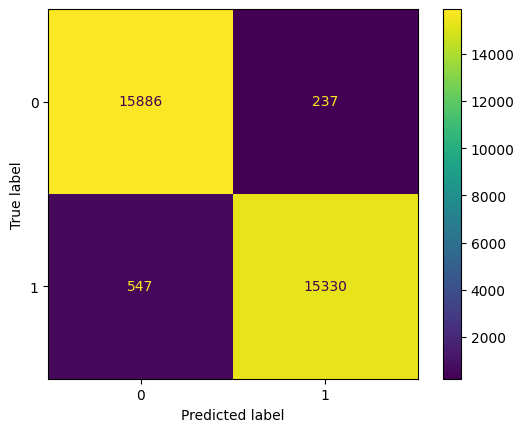

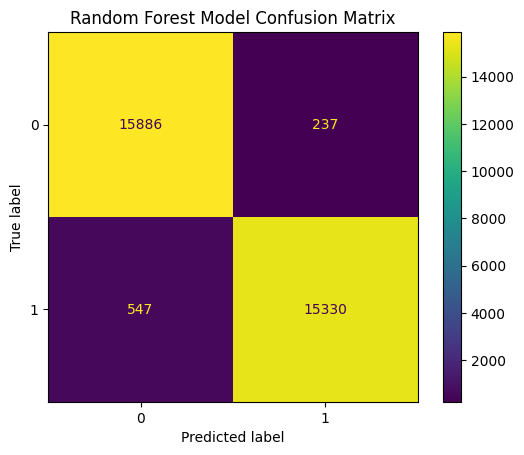

Model 'dga_model_rf.pkl' and vectorizer 'tfidf_vectorizer_xtrain.pkl' saved successfully.


In [3]:
# Cell 8931c924: Load data, train Random Forest, and define helper functions
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib # Added import for joblib
import numpy as np # Ensure numpy is imported

# Helper function to print results
def printRes(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    print(f'Accuracy: {accuracy}')
    print('Classification Report:')
    print(report)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_true))
    disp.plot()
    plt.show()

# Helper function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(title)
    plt.show()

# Load the dga_data.csv dataset
df = pd.read_csv('/content/dga_data.csv')
df = df.dropna()

# Convert 'isDGA' column to binary (0 or 1)
df['isDGA'] = df['isDGA'].apply(lambda x: 1 if x == 'dga' else 0)

# Extract features (host) and target variable (isDGA)
X = df['host']
y = df['isDGA']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit TfidfVectorizer on training data
tfidf_vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 5), max_features=100000) # Increased max_features for better representation
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Initialize and train RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_tfidf, y_train)

# Predict on the test set
y_pred = model_rf.predict(X_test_tfidf)

printRes(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred, 'Random Forest Model Confusion Matrix')

# Save the trained Random Forest model and TF-IDF vectorizer
joblib.dump(model_rf, 'dga_model_rf.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer_xtrain.pkl')
print("Model 'dga_model_rf.pkl' and vectorizer 'tfidf_vectorizer_xtrain.pkl' saved successfully.")

SVM Model (re-training and saving):
SVM Classification Results:
Accuracy: 0.994625
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     16123
           1       0.99      0.99      0.99     15877

    accuracy                           0.99     32000
   macro avg       0.99      0.99      0.99     32000
weighted avg       0.99      0.99      0.99     32000



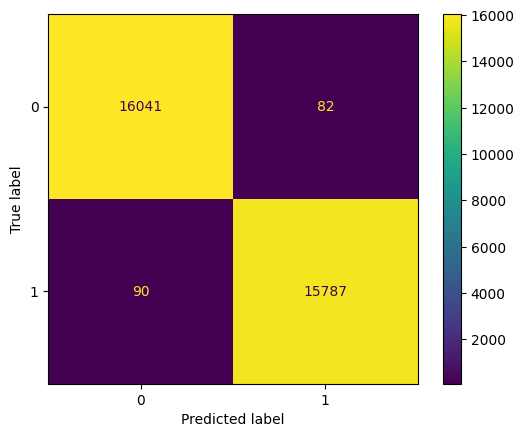

In [4]:
# Cell a82cac40: Train and save SVM model
from sklearn.svm import SVC

def svmModel(X_train_tfidf, y_train, X_test_tfidf, y_test):
    # Model for DGA/non-DGA classification
    model_dga = SVC(kernel='linear', random_state=42)
    model_dga.fit(X_train_tfidf, y_train)
    y_pred_isDGA = model_dga.predict(X_test_tfidf)

    print("SVM Classification Results:")
    # printRes is defined in the previous cell
    printRes(y_test, y_pred_isDGA)

    # Save the trained SVM model
    joblib.dump(model_dga, 'dga_model_svm.pkl')

print("SVM Model (re-training and saving):")
# X_train_tfidf, y_train, X_test_tfidf, y_test are available from the RandomForest training cell (previous cell).
# This uses the same vectorizer as RF for consistency.
svmModel(X_train_tfidf, y_train, X_test_tfidf, y_test)

Accuracy: 0.9755
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     16123
           1       0.98      0.97      0.98     15877

    accuracy                           0.98     32000
   macro avg       0.98      0.98      0.98     32000
weighted avg       0.98      0.98      0.98     32000



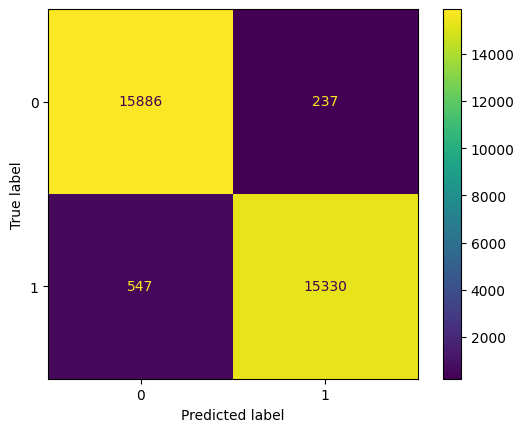

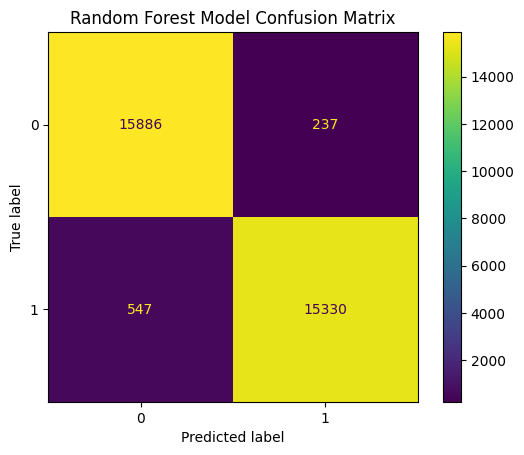

Model 'dga_model_rf.pkl' and vectorizer 'tfidf_vectorizer_xtrain.pkl' saved successfully.


In [3]:
# Cell 8931c924: Load data, train Random Forest, and define helper functions
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib # Added import for joblib
import numpy as np # Ensure numpy is imported

# Helper function to print results
def printRes(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    print(f'Accuracy: {accuracy}')
    print('Classification Report:')
    print(report)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_true))
    disp.plot()
    plt.show()

# Helper function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(title)
    plt.show()

# Load the dga_data.csv dataset
df = pd.read_csv('/content/dga_data.csv')
df = df.dropna()

# Convert 'isDGA' column to binary (0 or 1)
df['isDGA'] = df['isDGA'].apply(lambda x: 1 if x == 'dga' else 0)

# Extract features (host) and target variable (isDGA)
X = df['host']
y = df['isDGA']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit TfidfVectorizer on training data
tfidf_vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 5), max_features=100000) # Increased max_features for better representation
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Initialize and train RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_tfidf, y_train)

# Predict on the test set
y_pred = model_rf.predict(X_test_tfidf)

printRes(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred, 'Random Forest Model Confusion Matrix')

# Save the trained Random Forest model and TF-IDF vectorizer
joblib.dump(model_rf, 'dga_model_rf.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer_xtrain.pkl')
print("Model 'dga_model_rf.pkl' and vectorizer 'tfidf_vectorizer_xtrain.pkl' saved successfully.")


In [ ]:
# Cell a82cac40: Train and save SVM model
from sklearn.svm import SVC

def svmModel(X_train_tfidf, y_train, X_test_tfidf, y_test):
    # Model for DGA/non-DGA classification
    model_dga = SVC(kernel='linear', random_state=42)
    model_dga.fit(X_train_tfidf, y_train)
    y_pred_isDGA = model_dga.predict(X_test_tfidf)

    print("SVM Classification Results:")
    # printRes is defined in the previous cell
    printRes(y_test, y_pred_isDGA)

    # Save the trained SVM model
    joblib.dump(model_dga, 'dga_model_svm.pkl')

print("SVM Model (re-training and saving):")
# X_train_tfidf, y_train, X_test_tfidf, y_test are available from the RandomForest training cell (previous cell).
# This uses the same vectorizer as RF for consistency.
svmModel(X_train_tfidf, y_train, X_test_tfidf, y_test)


SVM Model (re-training and saving):


In [1]:
# Cell b95feee6: Evaluation of Random Forest on Validation Set
import joblib
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split

# --- Re-creating df_app.csv (validation data) if not already present or updated ---
# This section ensures df_app.csv is up-to-date and consistent with the trained model's data processing.
# Load the main dataset to derive the validation set based on the original data split logic.
original_df = pd.read_csv('/content/dga_data.csv')
original_df = original_df.dropna()
original_df['isDGA'] = original_df['isDGA'].apply(lambda x: 1 if x == 'dga' else 0)

# Re-split data to get the exact X_test and y_test used for df_app creation earlier
X_full = original_df[['domain', 'host']]
y_full = original_df['isDGA']
_, X_test_derived, _, y_test_derived = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

# Re-create df_app DataFrame to be used as df_val
num_samples_derived = len(y_test_derived)
base_date = datetime(2024, 6, 19) # Consistent with previous creation
times = [base_date + timedelta(seconds=np.random.randint(0, 86400)) for _ in range(num_samples_derived)]

df_val_recreated = pd.DataFrame({'Target': y_test_derived, 'Query': X_test_derived['domain'] + ' ' + X_test_derived['host'], 'Host': X_test_derived['host'], 'Time': [time.strftime('%Y-%m-%d %H:%M:%S') for time in times]})

# Convert 'Target' column for df_val_recreated to numerical labels (0/1)
df_val_recreated['Target_Label'] = df_val_recreated['Target'] # Use the numerical 'Target' column directly

# --- Load the trained model and vectorizer ---
# Using the paths where they were saved in the previous cell.
model_rf_loaded = joblib.load('dga_model_rf.pkl')
tfidf_vectorizer_loaded = joblib.load('tfidf_vectorizer_xtrain.pkl')

# --- Prepare validation data and make predictions ---
x_val_transformed_rf = tfidf_vectorizer_loaded.transform(df_val_recreated['Host']) # Use 'Host' column for RF
y_pred_val_rf = model_rf_loaded.predict(x_val_transformed_rf)

# --- Print results for Random Forest on validation set ---
print('--- Evaluation of Random Forest on Validation Set ---')
printRes(df_val_recreated['Target_Label'], y_pred_val_rf)


FileNotFoundError: [Errno 2] No such file or directory: '/content/dga_data.csv'

In [2]:
# Cell d08e83e9: Evaluation of SVM on Validation Set and comparison with RF
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load the SVM model
model_svm_loaded = joblib.load('dga_model_svm.pkl')

# Re-use the Random Forest vectorizer (tfidf_vectorizer_loaded) for SVM prediction as per previous context
svm_vect = tfidf_vectorizer_loaded

x_val_transformed_svm = svm_vect.transform(df_val_recreated['Host']) # Use 'Host' column for SVM consistency
y_pred_val_svm = model_svm_loaded.predict(x_val_transformed_svm)

print('\n--- Evaluation of SVM on Validation Set ---')
printRes(df_val_recreated['Target_Label'], y_pred_val_svm)

# Plotting both confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(df_val_recreated['Target_Label'], y_pred_val_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['legit', 'dga'])
disp_rf.plot(ax=axes[0], cmap=plt.cm.Blues)
axes[0].set_title('Random Forest Confusion Matrix')

# SVM Confusion Matrix
cm_svm = confusion_matrix(df_val_recreated['Target_Label'], y_pred_val_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['legit', 'dga'])
disp_svm.plot(ax=axes[1], cmap=plt.cm.Blues)
axes[1].set_title('SVM Confusion Matrix')

plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'dga_model_svm.pkl'